<a href="https://colab.research.google.com/github/muhh-b/heart_disease/blob/main/Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Data Mining Pipeline
## From Exploratory Data Analysis to Model Explainability



This notebook presents a complete end-to-end data mining pipeline for predicting heart disease using the **UCI Heart Disease dataset**. The objective is not only to build a predictive model, but also to follow a rigorous analytical methodology from raw data exploration to model interpretation and explainability.

The analysis is structured to reflect a realistic data science workflow. It begins with an exploratory study of the dataset to understand variable distributions, missing values, class balance, and potential patterns related to heart disease. It then moves to a leakage-free preprocessing and modeling pipeline, where multiple machine learning models are compared using appropriate evaluation metrics.

Beyond predictive performance, particular attention is given to **interpretability** and **practical relevance**. In a medical context, understanding why a model makes a prediction is as important as the prediction itself. For that reason, the notebook includes threshold analysis, calibration, and explainability techniques such as feature importance and SHAP-based interpretation.

The goal of this work is therefore twofold:
1. Build a robust model for heart disease prediction.
2. Extract meaningful insights that could support decision-making in a real-world screening context.

## Problem Definition

Heart disease remains one of the leading causes of mortality worldwide, making early detection a major public health challenge. Clinical datasets such as the UCI Heart Disease dataset provide an opportunity to explore how patient measurements and medical indicators can be used to support risk prediction.

In this notebook, the task is formulated as a **binary classification problem**:

- **0** → No heart disease
- **1** → Presence of heart disease

The objective is to predict whether a patient is likely to have heart disease based on a set of clinical and demographic features, including age, sex, chest pain type, cholesterol level, maximum heart rate, and other medical indicators.

This problem is especially interesting because it combines several important dimensions of data mining:
- structured tabular data analysis,
- missing value handling,
- feature engineering,
- model comparison,
- evaluation under different thresholds,
- and explainability of predictions.

Since this is a healthcare-related use case, model evaluation should not rely only on accuracy. Metrics such as **recall, precision, F1-score, ROC-AUC, and calibration** are essential to assess whether the model is both effective and usable in practice.

**Dataset source:** [UCI Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

## 📚 Table of Contents

1. [Setup and Data Loading](#-1-setup-and-data-loading)  
2. [Dataset Overview](#-2-dataset-overview)  
3. [Exploratory Data Analysis](#-3-exploratory-data-analysis)  
4. [Data Preprocessing](#-4-data-preprocessing)  
5. [Feature Engineering](#-5-feature-engineering)  
6. [Model Comparison](#-6-model-comparison)  
7. [Hyperparameter Tuning](#-7-hyperparameter-tuning)  
8. [Final Model Evaluation](#-8-final-model-evaluation)  
9. [Threshold Analysis](#-9-threshold-analysis)  
10. [Calibration Analysis](#-10-calibration-analysis)  
11. [Model Explainability](#-11-model-explainability)  
12. [Limitations and Future Improvements](#-12-limitations-and-future-improvements)  
13. [Conclusion](#-13-conclusion)

## 📦 1. Setup and Data Loading

In this section, we install and import the necessary libraries and load the dataset from the UCI Machine Learning Repository.

The goal is to prepare a clean and reproducible environment for the rest of the analysis.

### 🔧 1.1 Install and Import Required Libraries

We start by installing and importing the core libraries used throughout the notebook:
- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualization
- **scikit-learn** for preprocessing, modeling, and evaluation
- **xgboost** for advanced ensemble modeling
- **ucimlrepo** to fetch the dataset directly

In [1]:
# Install dependencies
!pip install ucimlrepo shap lime scikit-learn xgboost lightgbm matplotlib seaborn plotly pandas numpy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### 1.2 Load the Dataset

The dataset is retrieved directly from the UCI repository using the `ucimlrepo` package.  
It contains clinical and demographic features used to predict heart disease.

In [3]:
# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Features and target
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.squeeze().copy()

print("Dataset shape:", X.shape)
X.head()

Dataset shape: (303, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


### 1.3 Target Variable Transformation

The original target variable contains multiple classes representing different levels of heart disease severity.

For simplicity and clarity, we convert it into a **binary classification problem**:
- **0 → No disease**
- **1 → Presence of disease**

### Target Definition Note

The original target in the UCI Heart Disease dataset contains several severity levels (0 to 4). In this notebook, I convert it into a binary target: absence of disease (0) versus presence of disease (>0).

This choice is motivated by the objective of first-line detection rather than severity staging. However, this simplification reduces clinical granularity, and a multi-class or ordinal formulation could be explored in future work.

In [4]:
# Convert to binary classification
y = (y > 0).astype(int)

print("Target distribution:")
print(y.value_counts())

Target distribution:
num
0    164
1    139
Name: count, dtype: int64


### 1.4 Initial Data Inspection

We perform a quick inspection to understand:
- Data types
- Presence of missing values
- Basic structure of the dataset

In [5]:
# Data types and missing values
info_df = pd.DataFrame({
    "dtype": X.dtypes,
    "missing_values": X.isnull().sum(),
    "missing_%": (X.isnull().sum() / len(X) * 100).round(2)
})

info_df.sort_values("missing_values", ascending=False)

,dtype,missing_values,missing_%
ca,float64,4,1.32
thal,float64,2,0.66
cp,int64,0,0.00
sex,int64,0,0.00
age,int64,0,0.00
chol,int64,0,0.00
trestbps,int64,0,0.00
fbs,int64,0,0.00
restecg,int64,0,0.00
exang,int64,0,0.00


### Summary

- The dataset contains approximately **300 samples** and multiple clinical features.
- Some variables contain missing values that will require imputation.
- The target variable has been simplified into a binary classification problem.
- The dataset is relatively small, which requires careful validation to avoid overfitting.

We now proceed to exploratory data analysis to better understand the data.

## 2. Dataset Overview

Before diving into modeling, it is important to understand the structure and meaning of the variables.

The dataset consists of clinical and demographic features commonly used in cardiology to assess heart disease risk. Each row corresponds to a patient.

### Key Features

- **age**: Age of the patient  
- **sex**: Gender (1 = male, 0 = female)  
- **cp**: Chest pain type  
- **trestbps**: Resting blood pressure  
- **chol**: Serum cholesterol  
- **fbs**: Fasting blood sugar  
- **restecg**: Resting electrocardiographic results  
- **thalach**: Maximum heart rate achieved  
- **exang**: Exercise-induced angina  
- **oldpeak**: ST depression induced by exercise  
- **slope**: Slope of peak exercise ST segment  
- **ca**: Number of major vessels  
- **thal**: Thalassemia  

These features include both numerical and categorical variables, requiring different preprocessing strategies.

### Feature Types

We distinguish between numerical and categorical variables to guide preprocessing.

In [6]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


### Data Preview

We inspect a few rows to understand the structure and scale of the data.

In [7]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


## 3. Exploratory Data Analysis

Before building predictive models, it is essential to understand the structure, quality, and patterns of the data.

The goals of this EDA are to:

- assess class balance,
- identify missing values,
- study the distribution of numerical variables,
- compare feature behavior across target classes,
- explore relationships between variables,
- and generate insights that will guide preprocessing and modeling choices.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### 3.1 EDA Dataset Preparation

For visualization purposes, we combine the feature matrix and target into a single dataframe.

In [9]:
eda_df = X.copy()
eda_df["target"] = y

print("EDA dataframe shape:", eda_df.shape)
eda_df.head()

EDA dataframe shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### 3.2 Target Distribution

We first examine the target variable to understand class balance.

This is important because class imbalance can heavily influence both model choice and metric interpretation.

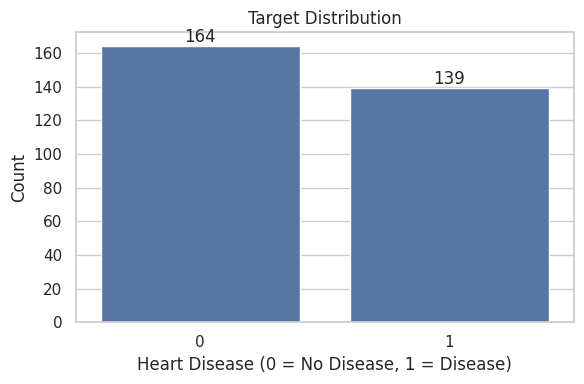

Class percentages:
target
0    54.13
1    45.87
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=eda_df, x="target")
plt.title("Target Distribution")
plt.xlabel("Heart Disease (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

target_pct = eda_df["target"].value_counts(normalize=True).sort_index() * 100
print("Class percentages:")
print(target_pct.round(2))

### 3.3 Missing Values Analysis

Missing data is a key aspect of data quality.  
We inspect the number and percentage of missing values for each feature.

In [11]:
missing_df = pd.DataFrame({
    "missing_count": X.isnull().sum(),
    "missing_percent": (X.isnull().sum() / len(X) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_df

,missing_count,missing_percent
ca,4,1.32
thal,2,0.66
cp,0,0.00
sex,0,0.00
age,0,0.00
chol,0,0.00
trestbps,0,0.00
fbs,0,0.00
restecg,0,0.00
exang,0,0.00


#### Missing Data Note

Missing values are concentrated in a small number of variables, especially `ca` and `thal`, which are clinically important predictors. Because the dataset is small, dropping rows would unnecessarily reduce sample size. For this reason, imputation is preferred, while acknowledging that imputed values may still introduce uncertainty in downstream interpretation.

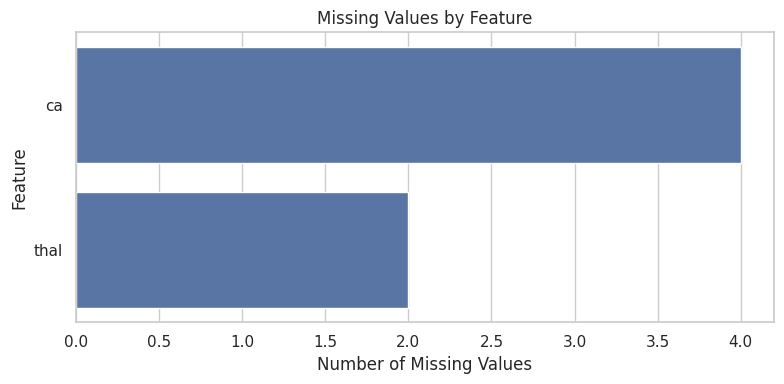

In [12]:
plt.figure(figsize=(8, 4))
missing_plot = missing_df[missing_df["missing_count"] > 0]

if len(missing_plot) > 0:
    sns.barplot(data=missing_plot.reset_index(), x="missing_count", y="index")
    plt.title("Missing Values by Feature")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")

### 3.4 Numerical Feature Distributions

We inspect the distribution of numerical variables to identify:
- skewness,
- unusual ranges,
- and potential outliers.

These insights help determine whether scaling and robust preprocessing are needed.

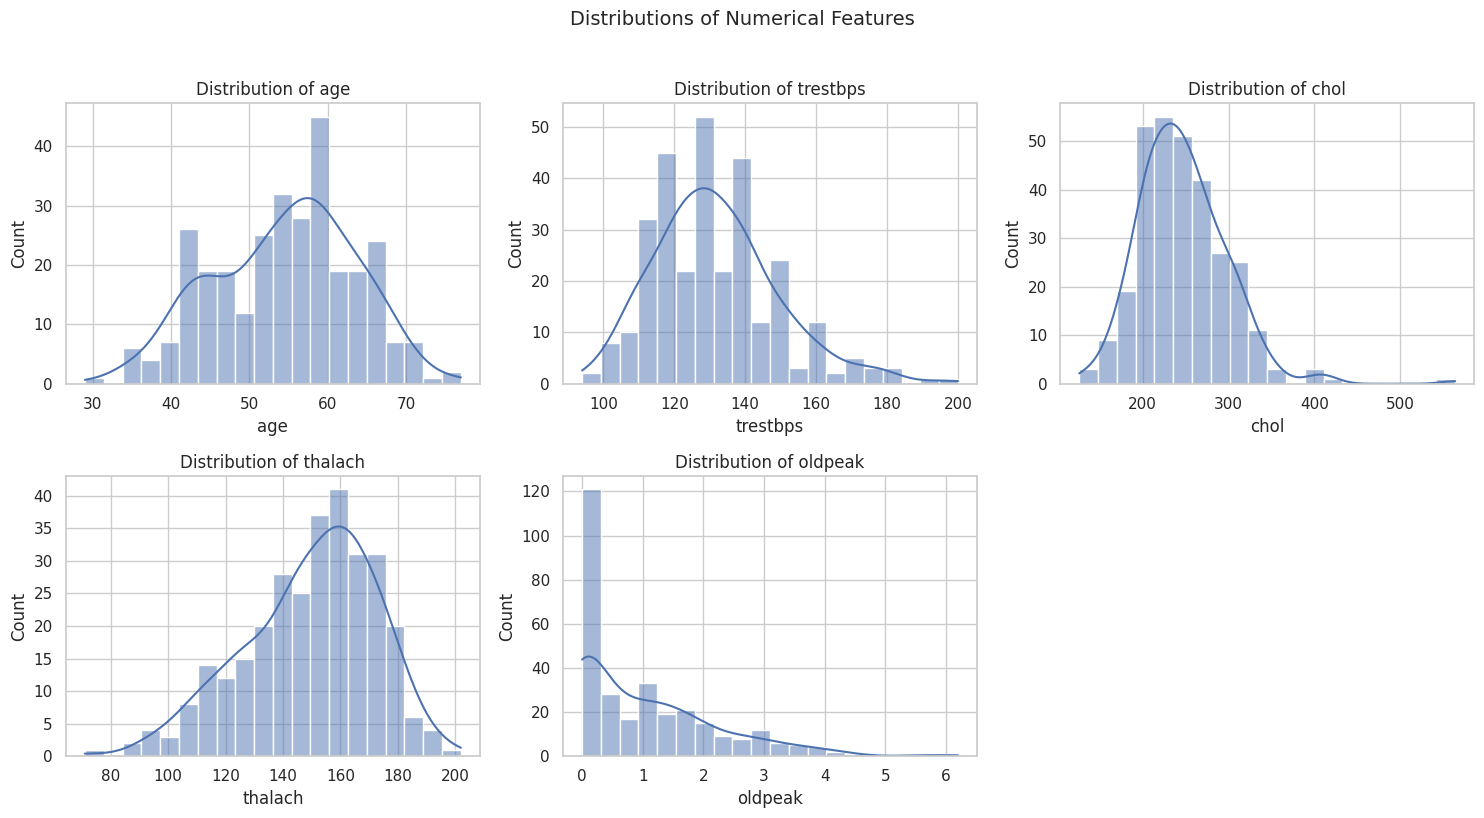

In [13]:
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=eda_df, x=col, kde=True, ax=axes[i], bins=20)
    axes[i].set_title(f"Distribution of {col}")

axes[-1].axis("off")
plt.suptitle("Distributions of Numerical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Numerical Distributions

Several important patterns emerge from the distributions:

- **age** is approximately normally distributed, centered around middle-aged patients, which is consistent with typical heart disease populations.

- **trestbps (resting blood pressure)** shows moderate spread with a slight right skew, indicating the presence of patients with elevated blood pressure.

- **chol (cholesterol)** exhibits a noticeable right skew with some extreme values, suggesting potential outliers and supporting the use of robust scaling.

- **thalach (maximum heart rate)** appears roughly normally distributed but slightly skewed, with higher values generally corresponding to better cardiovascular capacity.

- **oldpeak** is highly right-skewed, with many values near zero and a long tail. This suggests that most patients exhibit little ST depression, while a smaller group shows significant abnormalities.

### Implications for Modeling

- The presence of skewness and outliers justifies the use of **robust scaling** rather than standard scaling.
- Some variables (e.g., **oldpeak**) may carry strong predictive signal despite their skewed distribution.
- Feature transformations and non-linear models may better capture these patterns.

### 3.5 Numerical Summary Statistics

A summary table complements the visual inspection by showing the central tendency and dispersion of numerical variables.

In [14]:
eda_df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 3.6 Outlier Inspection

Boxplots help visualize outliers and compare the spread of numerical variables.

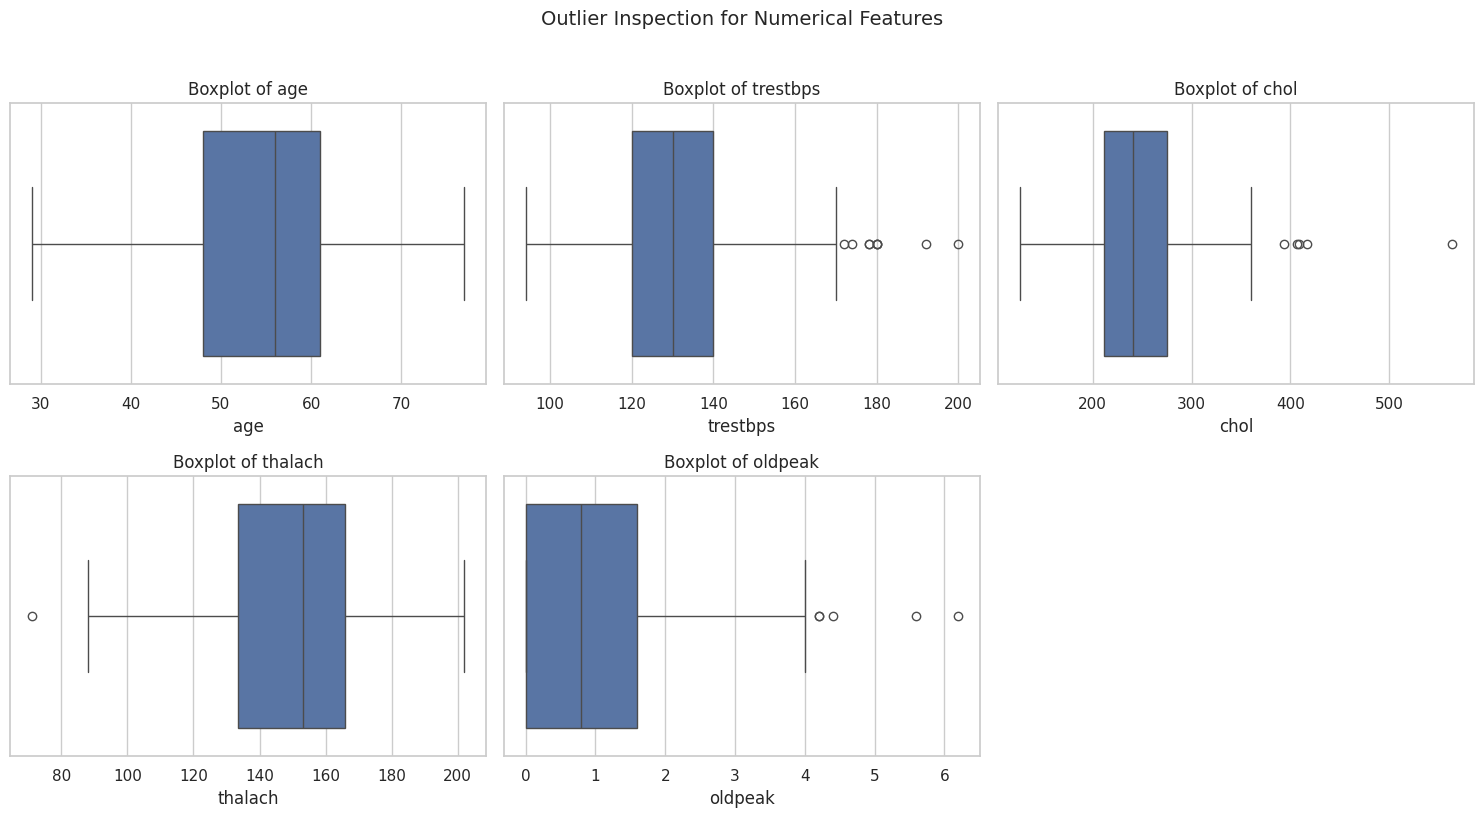

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=eda_df, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

axes[-1].axis("off")
plt.suptitle("Outlier Inspection for Numerical Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Outliers

The boxplots confirm that outliers are present in several numerical variables:

- **age** shows a relatively stable distribution with no major extreme values.
- **trestbps** contains several high-value outliers, indicating patients with unusually elevated resting blood pressure.
- **chol** presents notable right-tail outliers, including extreme cholesterol values.
- **thalach** has a small number of low-end outliers and a relatively wide overall spread.
- **oldpeak** shows the strongest asymmetry, with multiple high-value outliers consistent with its strong right-skew.

### Implications for Preprocessing

These observations support the use of **robust scaling**, which is less sensitive to extreme values than standard scaling.

At this stage, the outliers are **not removed**, since they may correspond to clinically meaningful high-risk patients rather than data errors. Instead, they are handled through robust preprocessing to preserve potentially important signal.

### 3.7 Numerical Features by Target Class

We now compare feature distributions across the two target classes.

This helps reveal variables that may be particularly informative for prediction.

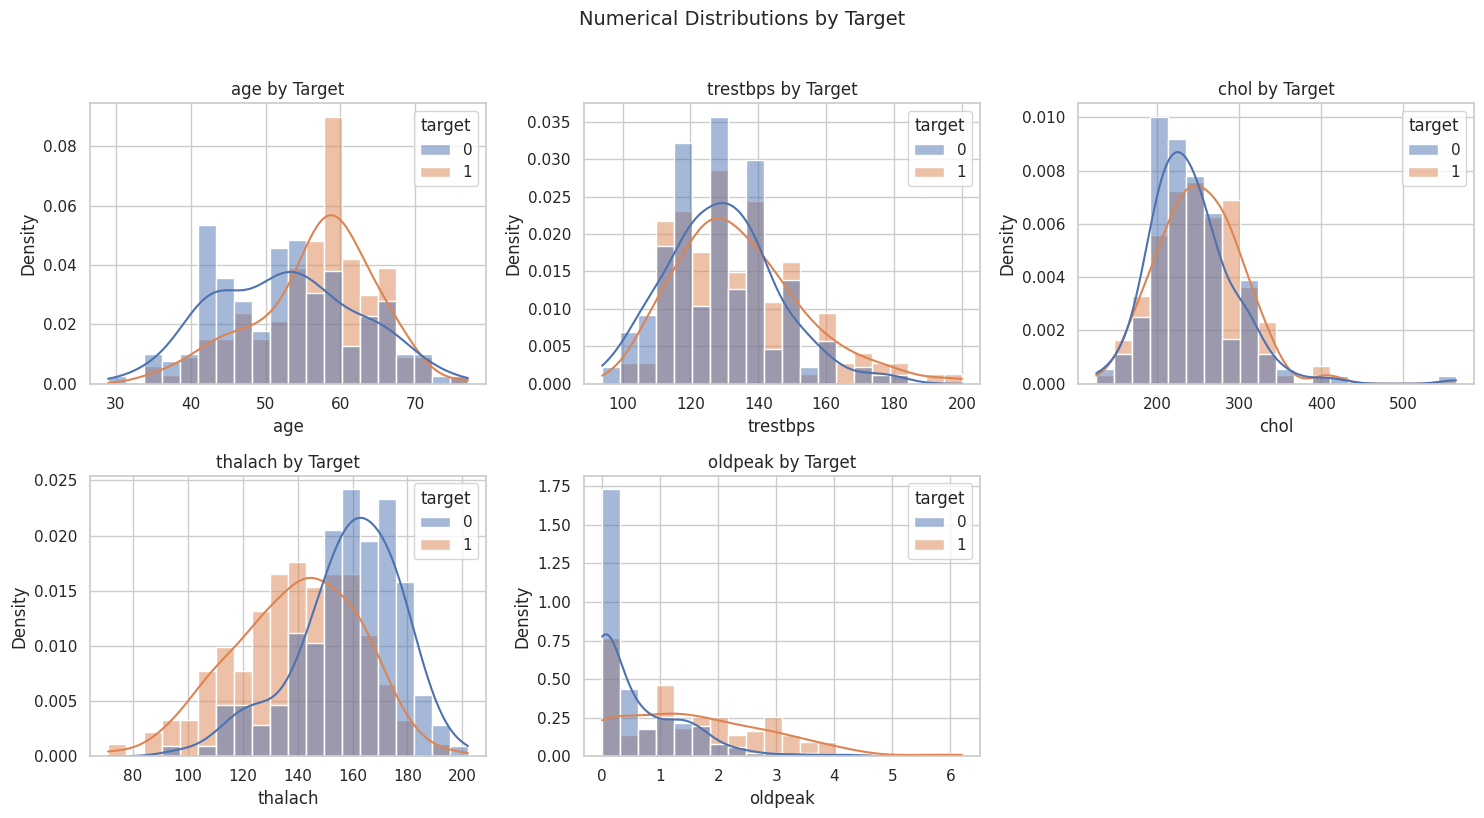

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=eda_df,
        x=col,
        hue="target",
        kde=True,
        bins=20,
        stat="density",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by Target")

axes[-1].axis("off")
plt.suptitle("Numerical Distributions by Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Feature Distributions by Target

Comparing distributions across target classes reveals which variables are most informative for prediction:

- **oldpeak** shows the clearest separation, with higher values strongly associated with the presence of heart disease. This suggests it is a highly predictive feature.

- **thalach (maximum heart rate)** displays an inverse relationship: patients with heart disease tend to have lower maximum heart rates.

- **age** shows a moderate shift, with patients with heart disease tending to be slightly older on average.

- **trestbps (resting blood pressure)** and **chol (cholesterol)** exhibit substantial overlap between classes, indicating weaker discriminative power on their own.

### Key Insight

Not all variables contribute equally to prediction.  
Features such as **oldpeak** and **thalach** are likely to be strong drivers of model performance, while others may require interaction effects or non-linear modeling to be useful.

### Implication for Modeling

- Models capable of capturing **non-linear relationships** (e.g., tree-based methods) may better exploit these patterns.
- Feature importance and explainability analysis will help confirm these observations.

### 3.8 Boxplots by Target

Boxplots by target provide a compact way to compare medians, spread, and potential separation between classes.

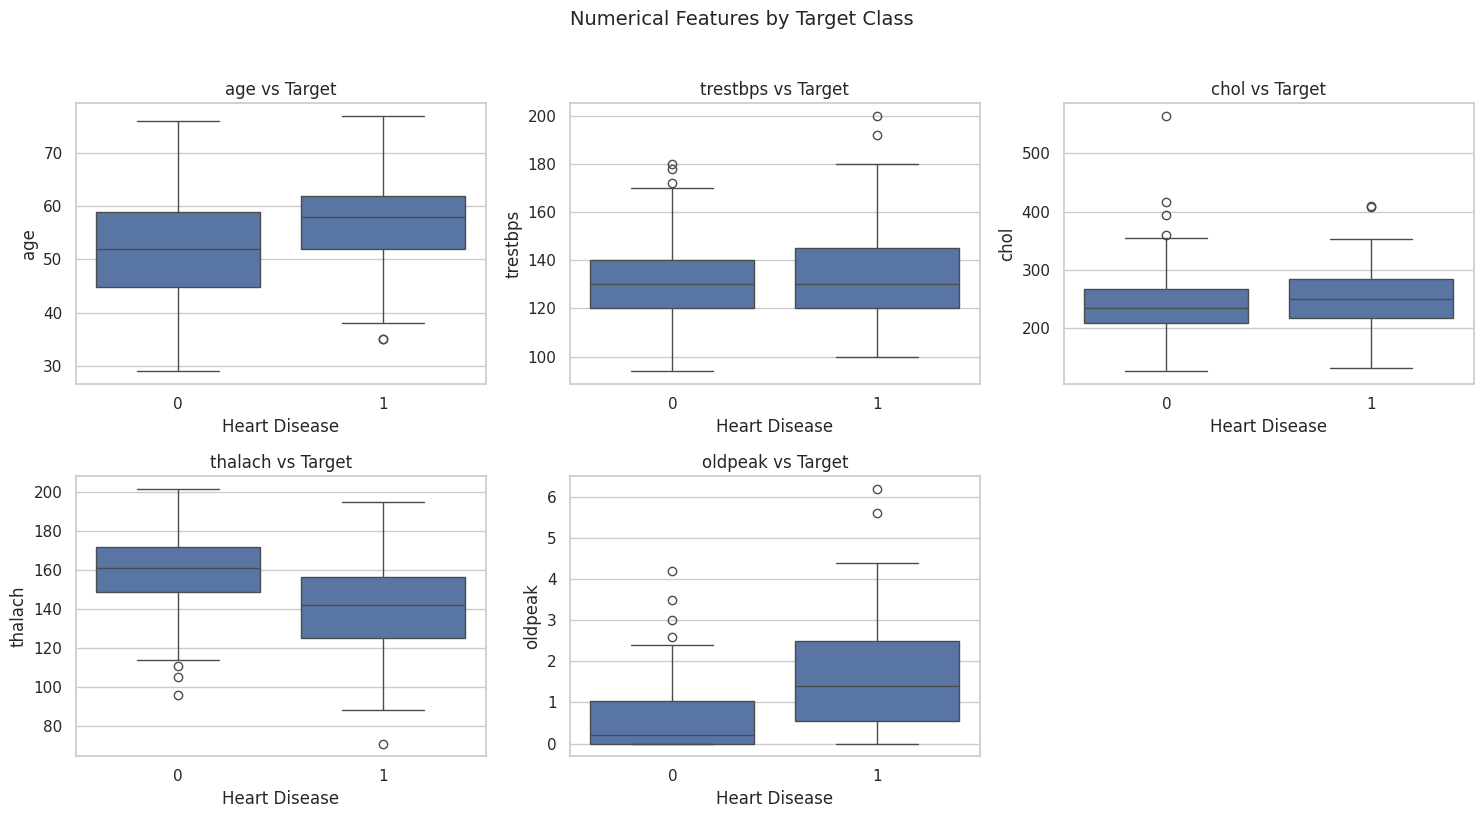

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=eda_df, x="target", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xlabel("Heart Disease")

axes[-1].axis("off")
plt.suptitle("Numerical Features by Target Class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Numerical Features by Target

The boxplots highlight differences in feature distributions between patients with and without heart disease:

- **oldpeak** shows the strongest separation, with significantly higher values in patients with heart disease. This suggests it is a highly informative feature.

- **thalach (maximum heart rate)** exhibits an inverse relationship: patients with heart disease tend to have lower maximum heart rates.

- **age** shows a moderate upward shift in patients with heart disease, indicating increased risk with age.

- **trestbps (resting blood pressure)** and **chol (cholesterol)** display substantial overlap between classes, suggesting weaker discriminative power when considered individually.

### Key Insight

Not all features contribute equally to prediction.  
Variables such as **oldpeak** and **thalach** show clear class separation and are likely to be strong predictors, while others may require interaction effects or non-linear modeling to become useful.

### Implications for Modeling

- Tree-based models (e.g., Random Forest, XGBoost) may better capture non-linear relationships present in the data.
- Feature importance and SHAP analysis will be used later to confirm these observations.

### 3.9 Categorical Feature Distributions

We inspect categorical variables to understand the frequency of each category.

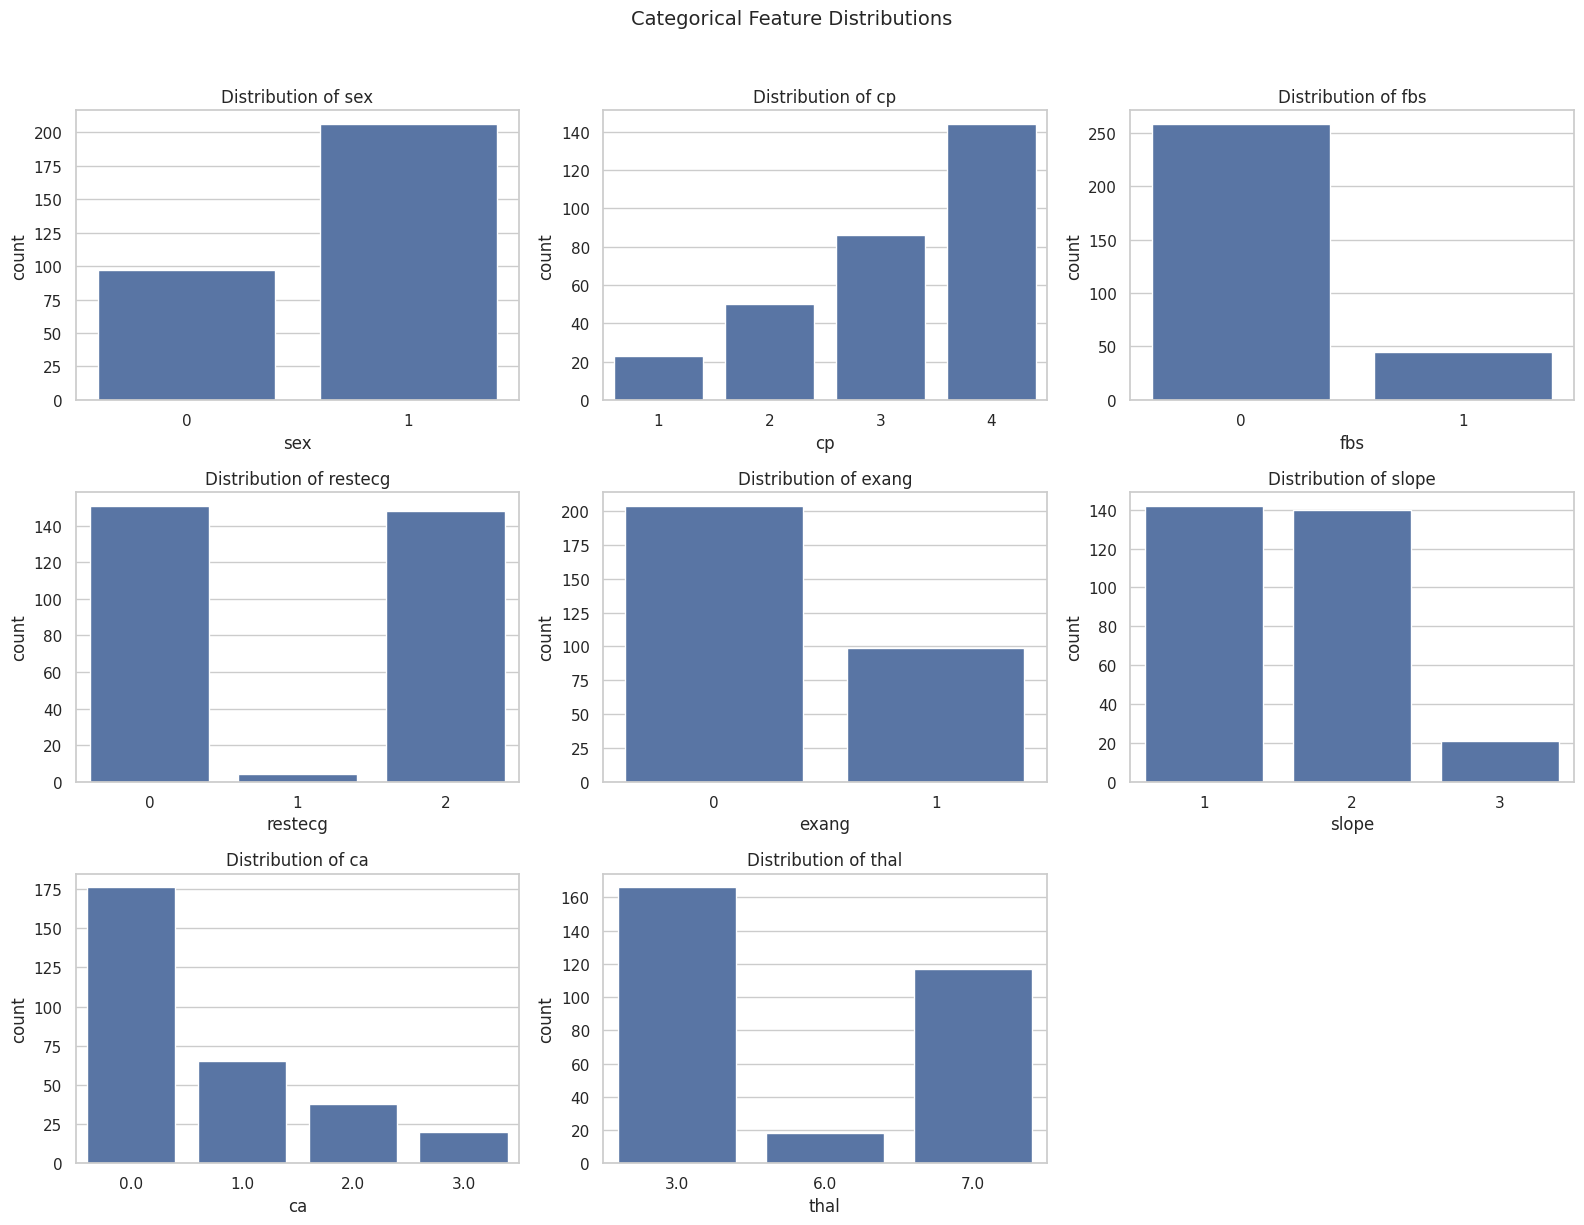

In [18]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=eda_df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

axes[-1].axis("off")
plt.suptitle("Categorical Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Categorical Feature Distributions

The categorical variables show heterogeneous frequency patterns:

- **sex** is imbalanced, with category `1` more frequent than category `0`.
- **cp** (chest pain type) is unevenly distributed, suggesting that some symptom categories are much more common than others.
- **fbs** has a dominant majority class, which may limit its discriminative power on its own.
- **restecg** includes a very rare category, which should be interpreted cautiously.
- **ca** is heavily concentrated at `0`, while higher values are progressively rarer.
- **thal** is mainly concentrated in categories `3` and `7`.

### Implications for Preprocessing

These observations confirm that:
- the dataset contains several genuinely **categorical predictors**,
- some variables have **rare categories**,
- and **one-hot encoding** is an appropriate preprocessing strategy.

However, frequency alone does not indicate predictive value.  
To assess which categorical features are truly informative, they must be analyzed **in relation to the target variable**.

### 3.10 Categorical Features by Target Class

We compare categorical distributions across target classes to identify strong class associations.

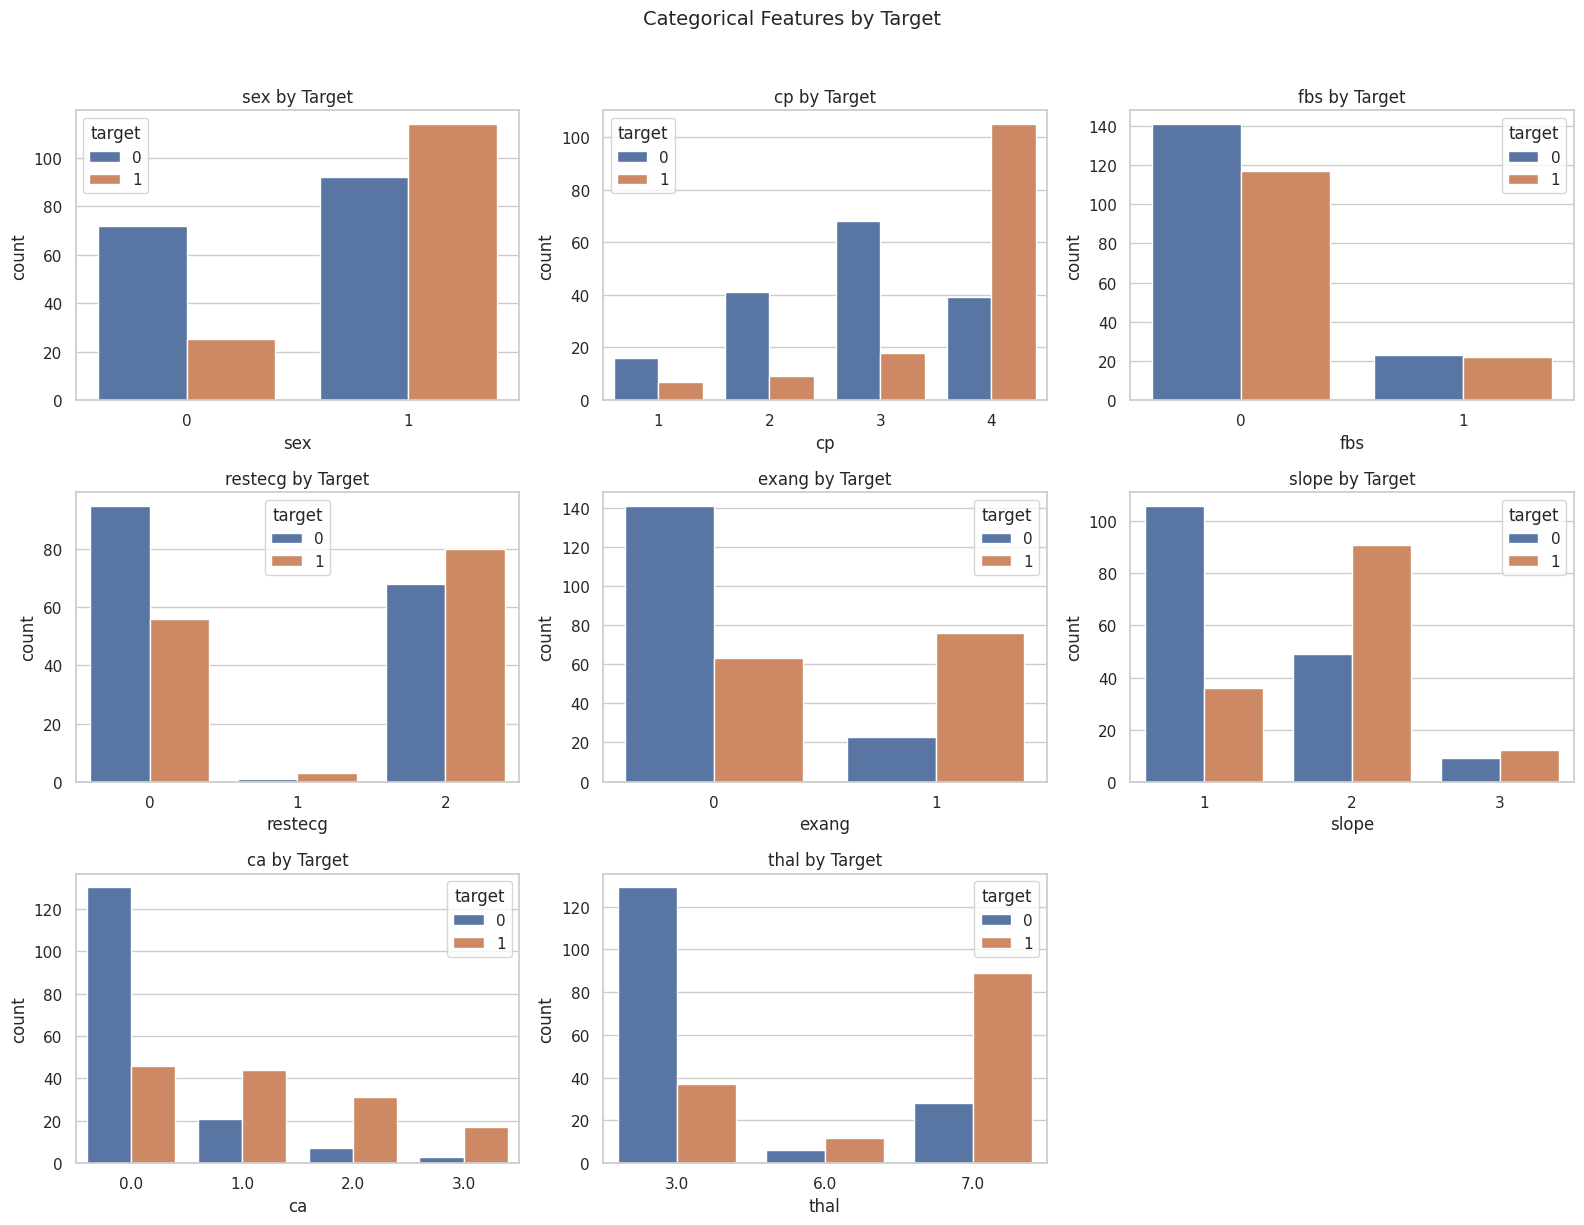

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=eda_df, x=col, hue="target", ax=axes[i])
    axes[i].set_title(f"{col} by Target")

axes[-1].axis("off")
plt.suptitle("Categorical Features by Target", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation of Categorical Features by Target

The categorical variables reveal strong differences in distribution between patients with and without heart disease:

- **cp (chest pain type)** shows one of the strongest signals. Certain categories (notably higher values) are much more associated with heart disease, making it a highly informative feature.

- **ca (number of major vessels)** displays a clear pattern: higher values are strongly associated with the presence of heart disease, while `0` is predominantly associated with no disease.

- **thal (thalassemia status)** also shows strong separation, with certain categories (e.g., `7`) being much more frequent among patients with heart disease.

- **exang (exercise-induced angina)** is clearly informative, as patients with `exang = 1` are more likely to have heart disease.

- **slope** shows moderate differences between classes, suggesting some predictive value.

- **sex** indicates that male patients (`sex = 1`) are more frequently associated with heart disease in this dataset.

- **fbs** and **restecg** exhibit relatively similar distributions across classes, suggesting limited discriminative power when considered independently.

### Key Insight

Several categorical variables (**cp, ca, thal, exang**) show strong class separation and are likely to be among the most important predictors in the model.

### Implications for Modeling

- These features are expected to play a major role in model performance.
- Proper encoding (e.g., one-hot encoding) is essential to capture their contribution.
- Feature importance and SHAP analysis will later confirm their impact.

### 3.11 Correlation Analysis

We analyze correlations between numerical features to detect linear relationships and possible redundancy.

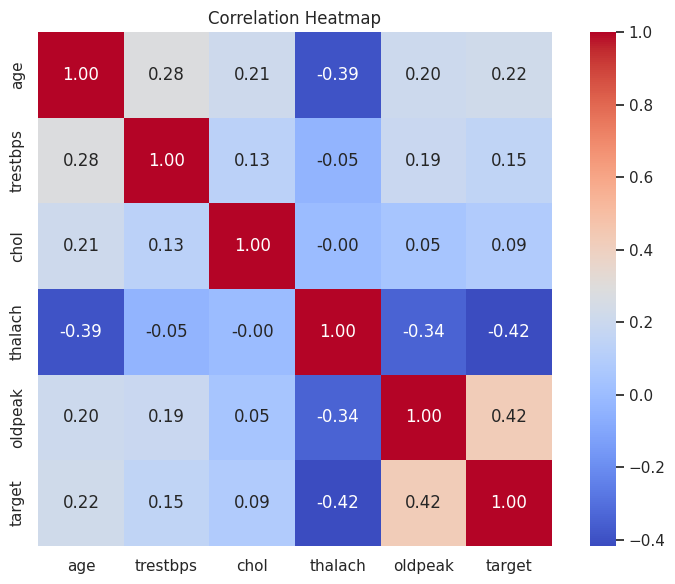

In [20]:
corr = eda_df[numerical_cols + ["target"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation heatmap provides insight into linear relationships between numerical features and the target variable.

### Key Observations

- **oldpeak** shows the strongest positive correlation with the target (**~0.42**), suggesting that higher ST depression is associated with increased likelihood of heart disease.

- **thalach (maximum heart rate)** has the strongest negative correlation with the target (**~ -0.42**), indicating that lower maximum heart rate is associated with heart disease.

- **age** has a moderate positive correlation (**~0.22**), suggesting that older patients are slightly more at risk.

- **trestbps** and **chol** show weak correlations with the target, confirming earlier observations that they may have limited standalone predictive power.

### Feature Relationships

- **oldpeak and thalach** are negatively correlated (**~ -0.34**), suggesting potential interaction effects between exercise-related variables.

- No strong multicollinearity is observed between features, which is beneficial for model stability, especially for linear models.

### Key Insight

The strongest linear signals come from **oldpeak** and **thalach**, which aligns with previous EDA findings. This consistency reinforces their importance as predictive features.

### Important Note

Correlation only captures linear relationships. Some variables with low correlation (e.g., categorical features like **cp, ca, thal**) may still be highly predictive through non-linear effects, which will be captured by tree-based models.

The consistency between correlation analysis and previous visual exploration strengthens confidence in the identified predictive features.

### 3.12 Correlation with Target

We inspect which numerical variables are most linearly associated with the target.

In [21]:
target_corr = corr["target"].drop("target").sort_values(key=np.abs, ascending=False)
target_corr

,target
oldpeak,0.424510
thalach,-0.417167
age,0.223120
trestbps,0.150825
chol,0.085164


### Correlation with Target (Feature Ranking)

To better understand the relationship between numerical features and the target, we rank features by their absolute correlation with heart disease.

### Results

- **oldpeak** shows the strongest positive correlation (**0.42**), making it the most informative numerical feature.
- **thalach** has a strong negative correlation (**-0.42**), indicating that lower maximum heart rate is associated with heart disease.
- **age** shows a moderate positive relationship (**0.22**).
- **trestbps** and **chol** exhibit weak correlations, suggesting limited predictive power when used alone.

### Key Insight

This ranking confirms previous visual analysis:
- **oldpeak** and **thalach** consistently emerge as the most important numerical features.
- Other variables may require non-linear modeling or interactions to contribute effectively.

### Important Note

Correlation reflects only linear relationships. Features with low correlation may still be important in non-linear models such as Random Forest or Gradient Boosting.

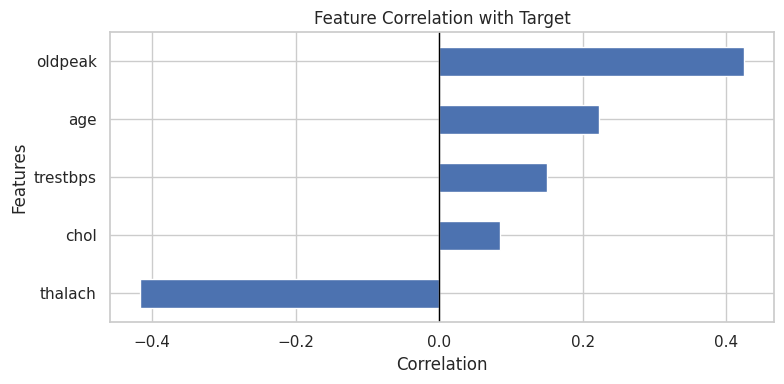

In [22]:
plt.figure(figsize=(8, 4))

target_corr.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

### 3.13 Creative Visualization

To enrich the analysis, we project three clinically relevant variables into a 3D space:

- `age`
- `thalach` (maximum heart rate)
- `oldpeak` (exercise-induced ST depression)

This helps visualize how patients with and without heart disease distribute across multiple dimensions simultaneously.

In [23]:
import plotly.express as px

plot_df = eda_df[["age", "thalach", "oldpeak", "target"]].dropna().copy()
plot_df["target_label"] = plot_df["target"].map({0: "No Disease", 1: "Disease"})

fig = px.scatter_3d(
    plot_df,
    x="age",
    y="thalach",
    z="oldpeak",
    color="target_label",
    opacity=0.75,
    title="3D Visualization of Patients by Age, Maximum Heart Rate, and ST Depression"
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### Interpretation of the 3D Visualization

This 3D scatter plot highlights the joint relationship between **age**, **maximum heart rate (`thalach`)**, and **ST depression (`oldpeak`)**, with color indicating heart disease status.

Several patterns can be observed:

- Patients with **heart disease** tend to appear more frequently at **higher `oldpeak` values**, suggesting that ST depression is one of the most discriminative numerical features in the dataset.
- Patients without heart disease are more concentrated around **lower `oldpeak` values** and often show **higher `thalach`**.
- **Age** shows a weaker trend, with some tendency for patients with heart disease to be older on average, but with substantial overlap between classes.
- The separation between classes appears to come more from the **combination of variables** than from any single feature taken alone.

### Key Insight

This visualization suggests that heart disease status is better explained by a **multivariate pattern** rather than a simple threshold on one variable. In particular, the combination of **higher `oldpeak`**, **lower `thalach`**, and, to a lesser extent, **older age** seems associated with a higher likelihood of heart disease.

### Implication for Modeling

The overlap visible in 3D supports the use of models capable of capturing **interactions** and **non-linear relationships** between variables. It also motivates the later use of feature importance and SHAP analysis to verify whether the learned patterns are consistent with the trends observed during EDA.µ

### 3.14 Key Insights from EDA

The exploratory analysis highlights several important patterns:

- The dataset is relatively small, which calls for careful validation and cautious interpretation.
- Missing values are concentrated in a few variables, especially `ca` and `thal`, making imputation necessary.
- Some numerical features, particularly **oldpeak** and **thalach**, show visible separation between patients with and without heart disease.
- Several categorical variables, such as **cp**, **exang**, and **ca**, appear strongly associated with the target.
- Outliers and skewness are present in some numerical variables, which supports the use of **robust scaling**.
- The 3D visualization suggests that disease presence is influenced by a combination of clinical variables rather than a single feature in isolation.

These findings directly inform the preprocessing, feature engineering, and model selection strategy used in the next sections.

## 4. Data Preprocessing

In this section, we prepare the data for modeling while ensuring **methodological rigor**.

A key objective is to **avoid data leakage**, which occurs when information from the test set influences the training process. This can lead to overly optimistic performance estimates.

### Strategy

To prevent leakage:
- The dataset has already been split into **training and test sets**
- All preprocessing steps are applied **within a pipeline**
- Transformations are learned only from training data during cross-validation

### Preprocessing Steps

We apply different transformations depending on feature types:

- **Numerical features**
  - Missing values → Median imputation
  - Scaling → RobustScaler (resistant to outliers)

- **Categorical features**
  - Missing values → Most frequent imputation
  - Encoding → One-hot encoding

This ensures a consistent and reproducible transformation process across models.

### 4.1 Feature Groups

We separate numerical and categorical variables to apply appropriate preprocessing.

In [24]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

### 4.2 Preprocessing Pipelines

We define separate pipelines for numerical and categorical features, then combine them using a `ColumnTransformer`.

This modular approach ensures that each transformation is applied correctly and consistently.

In [25]:
# Numerical pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### Why RobustScaler?

RobustScaler is used for numerical variables because it is less sensitive to outliers than standard scaling. This is useful in small clinical datasets, where a few extreme values may otherwise disproportionately influence the transformation.

## 5. Feature Engineering

Feature engineering aims to enrich the original dataset with derived variables that may better capture clinically meaningful patterns.

Rather than relying only on raw measurements, we create a small set of additional features motivated by both domain intuition and EDA findings.

### Objectives

The engineered features are designed to capture:

- **relative physiological relationships**, rather than isolated measurements,
- **simplified risk indicators** that may be easier for models to exploit,
- and **interaction effects** between variables linked to exercise and cardiac stress.

To preserve methodological rigor, feature engineering is implemented **inside the modeling pipeline** through a custom transformer.  
This ensures that:
- transformations are applied consistently,
- they remain leakage-free,
- and they are included properly during cross-validation.

### 5.1 Rationale for Engineered Features

Based on exploratory analysis and basic clinical intuition, the following derived features are introduced:

- **hr_age_ratio**  
  Ratio between maximum heart rate and age. This captures whether heart rate response is relatively high or low given the patient's age.

- **oldpeak_thalach_ratio**  
  Ratio between exercise-induced ST depression (`oldpeak`) and maximum heart rate (`thalach`). This reflects exercise-related cardiac stress relative to physiological capacity.

- **hypertension**  
  Binary indicator derived from resting blood pressure (`trestbps > 140`), used as a simplified cardiovascular risk flag.

- **high_chol**  
  Binary indicator derived from cholesterol (`chol > 240`), representing elevated cholesterol levels.

These features are not meant to replace the original variables, but to complement them with more interpretable and potentially more predictive signals.

### 5.2 Custom Transformer

We define a custom scikit-learn transformer so that feature engineering can be integrated directly into the pipeline.

In [27]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Ratio between max heart rate and age
        X["hr_age_ratio"] = X["thalach"] / X["age"].replace(0, np.nan)

        # Relative exercise stress indicator
        X["oldpeak_thalach_ratio"] = X["oldpeak"] / (X["thalach"] + 1e-6)

        # Simplified binary cardiovascular indicators
        X["hypertension"] = (X["trestbps"] > 140).astype(int)
        X["high_chol"] = (X["chol"] > 240).astype(int)

        return X

### 5.3 Preview of Engineered Features

Before integrating these variables into the full pipeline, we inspect a preview of the transformed dataset.

In [28]:
X_fe_preview = FeatureEngineer().fit_transform(X)

X_fe_preview[[
    "age", "thalach", "oldpeak", "trestbps", "chol",
    "hr_age_ratio", "oldpeak_thalach_ratio", "hypertension", "high_chol"
]].head()

,age,thalach,oldpeak,trestbps,chol,hr_age_ratio,oldpeak_thalach_ratio,hypertension,high_chol
0,63,150,2.3,145,233,2.380952,0.015333,1,0
1,67,108,1.5,160,286,1.611940,0.013889,1,1
2,67,129,2.6,120,229,1.925373,0.020155,0,0
3,37,187,3.5,130,250,5.054054,0.018717,0,1
4,41,172,1.4,130,204,4.195122,0.008140,0,0


### 5.4 Distribution of Engineered Features

We inspect the distribution of the new features to ensure they are meaningful and well-formed.





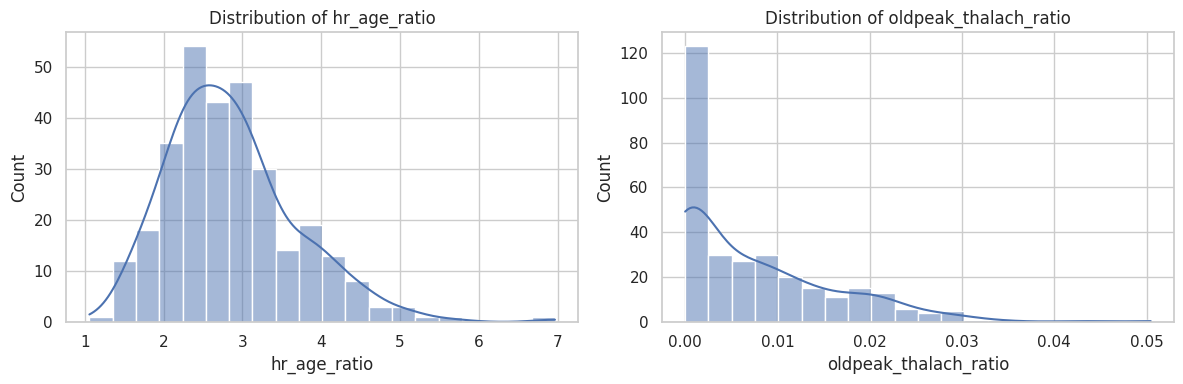

In [29]:
engineered_numerical = ["hr_age_ratio", "oldpeak_thalach_ratio"]
engineered_binary = ["hypertension", "high_chol"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(engineered_numerical):
    sns.histplot(data=X_fe_preview, x=col, kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### Interpretation of Engineered Feature Distributions

The engineered features show distinct distribution patterns:

- **hr_age_ratio** exhibits a relatively smooth and unimodal distribution, suggesting it is well-behaved and suitable for modeling.

- **oldpeak_thalach_ratio** is highly right-skewed, with most values concentrated near zero and a long tail of higher values. This may reflect rare but extreme physiological conditions.

### Key Insight

The engineered features introduce new perspectives by combining clinically related variables:
- **hr_age_ratio** captures the relationship between cardiovascular capacity and age.
- **oldpeak_thalach_ratio** reflects the interaction between ST depression and heart rate response.

### Considerations

- The skewness of **oldpeak_thalach_ratio** suggests that scaling or tree-based models may be more appropriate.
- Extreme values may carry important signal but should be handled carefully to avoid instability in linear models.

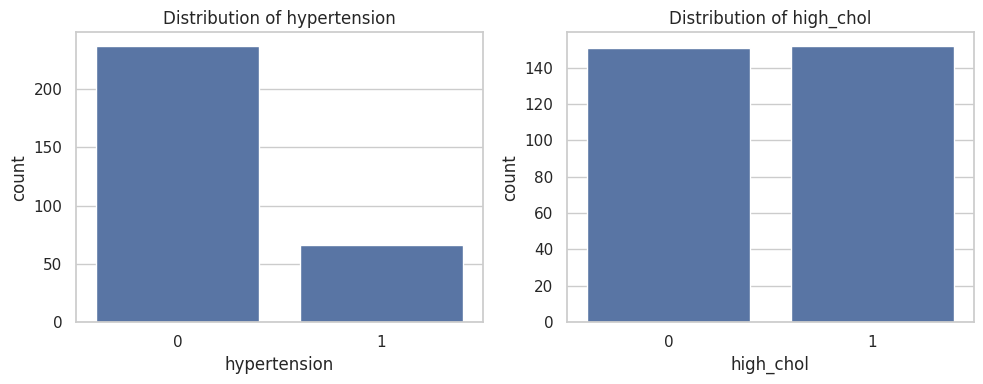

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(engineered_binary):
    sns.countplot(data=X_fe_preview, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### 5.5 Engineered Features by Target

We compare the engineered features across target classes to assess whether they introduce useful signal.

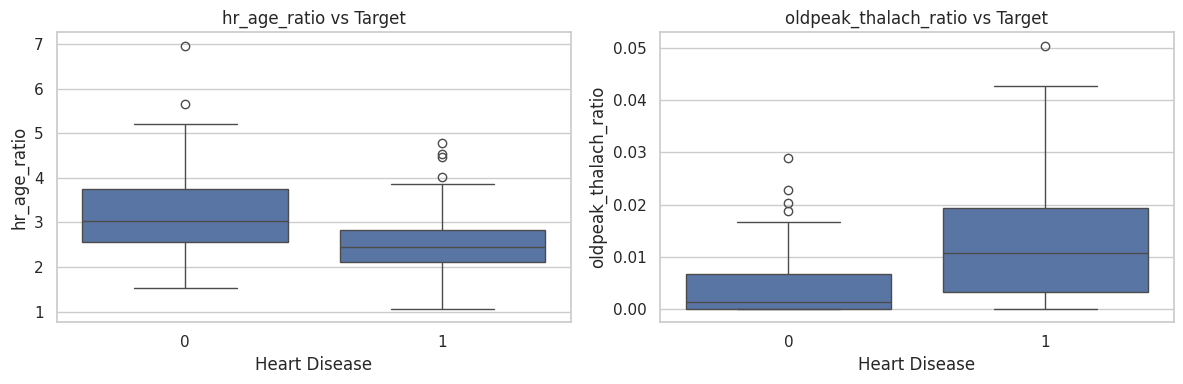

In [31]:
fe_eda_df = X_fe_preview.copy()
fe_eda_df["target"] = y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(engineered_numerical):
    sns.boxplot(data=fe_eda_df, x="target", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_xlabel("Heart Disease")

plt.tight_layout()
plt.show()

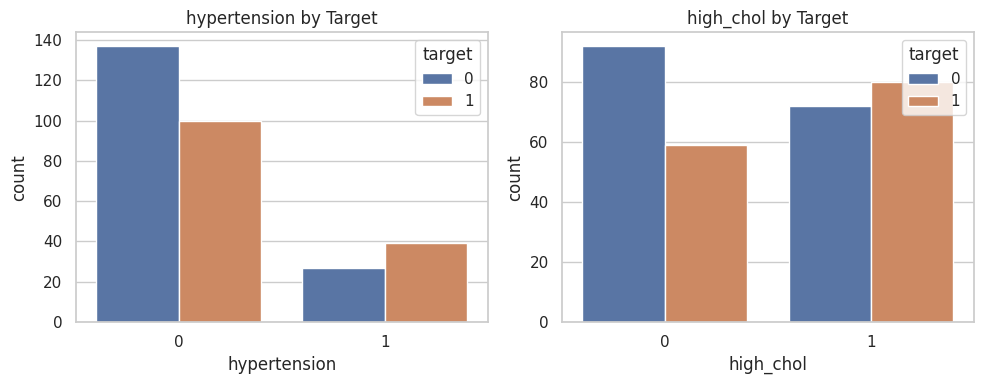

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(engineered_binary):
    sns.countplot(data=fe_eda_df, x=col, hue="target", ax=axes[i])
    axes[i].set_title(f"{col} by Target")

plt.tight_layout()
plt.show()

### Interpretation of Engineered Features

The engineered features provide additional perspectives beyond the original variables:

- **hr_age_ratio** shows a clear shift between classes, with lower values more frequently associated with heart disease. This suggests that the relationship between age and maximum heart rate carries useful predictive signal.

- **oldpeak_thalach_ratio** displays the strongest class separation among the engineered features. Higher values are more common in patients with heart disease, indicating that combining ST depression with heart rate captures an informative interaction effect.

- **hypertension** shows a moderate difference between target classes, which supports its use as a simple binary cardiovascular risk indicator.

- **high_chol** appears modestly informative, with elevated cholesterol somewhat more common among patients with heart disease.

### Key Insight

The engineered features do not simply duplicate the original variables.  
They appear to capture:
- relative physiological relationships,
- clinically meaningful threshold effects,
- and interaction structure that may improve model performance.

### Implication for Modeling

These features are retained in the pipeline because they add interpretable structure while remaining simple enough to avoid unnecessary complexity.

Among the engineered features, `oldpeak_thalach_ratio` and `hr_age_ratio` appear the most promising based on visible class separation.

### 5.6 Updated Feature Groups

After feature engineering, we update the feature lists used in preprocessing.

In [33]:
numeric_features_fe = numeric_features + ["hr_age_ratio", "oldpeak_thalach_ratio"]
categorical_features_fe = categorical_features + ["hypertension", "high_chol"]

print("Numerical features after feature engineering:")
print(numeric_features_fe)

print("\nCategorical features after feature engineering:")
print(categorical_features_fe)

Numerical features after feature engineering:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'hr_age_ratio', 'oldpeak_thalach_ratio']

Categorical features after feature engineering:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'hypertension', 'high_chol']


### 5.7 Feature Engineering Inside the Pipeline

We integrate the custom transformer into the preprocessing pipeline to ensure that feature engineering is applied consistently and without leakage.

In [34]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = Pipeline(steps=[
    ("feature_engineering", FeatureEngineer()),
    ("column_transformer", ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features_fe),
            ("cat", categorical_transformer, categorical_features_fe)
        ],
        remainder="drop"
    ))
])

#### Train/Test Split

Before transforming the data, we create a stratified train/test split to preserve the class distribution in both subsets. This ensures that preprocessing, model selection, and evaluation remain properly separated.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (242, 13)
Test shape: (61, 13)
Train target distribution:
num
0    0.541322
1    0.458678
Name: proportion, dtype: float64
Test target distribution:
num
0    0.540984
1    0.459016
Name: proportion, dtype: float64


### 5.8 Sanity Check

We verify that the full preprocessing pipeline works correctly on the training and test sets.

In [36]:
# Make sure train/test split has already been run before this cell
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed test shape:", X_test_transformed.shape)

Transformed training shape: (242, 34)
Transformed test shape: (61, 34)


### 5.9 Interpretation

The engineered features enrich the dataset in three useful ways:

- They introduce **relative measures** that may better reflect patient condition than raw variables alone.
- They provide **simplified binary indicators** for common cardiovascular risk factors.
- They allow the models to capture clinically relevant patterns with minimal added complexity.

Because these features are integrated within the pipeline, they are evaluated fairly during cross-validation and model comparison.

### 5.10 Summary

Feature engineering was used to add a small number of clinically motivated derived variables:

- `hr_age_ratio`
- `oldpeak_thalach_ratio`
- `hypertension`
- `high_chol`

These features are incorporated directly into the preprocessing pipeline, ensuring that the full workflow remains reproducible and leakage-free.

We now move to model comparison to assess whether these preprocessing choices improve predictive performance.

## 6. Model Comparison

In this section, we compare several machine learning models to identify the most suitable approach for heart disease prediction.

Rather than exhaustively testing many algorithms, we adopt a focused and representative comparison strategy that balances:

- methodological rigor,
- model diversity,
- interpretability,
- and dataset constraints.

Given the relatively small size of the dataset (~300 samples), evaluating too many models could introduce noise and reduce the reliability of comparisons.

Instead, we select a small set of complementary model families that capture different learning paradigms.

### 6.1 Model Selection Strategy

To ensure both diversity and clarity, we select four representative models:

- **Logistic Regression**  
  A linear, interpretable baseline that provides a strong reference point.

- **Random Forest**  
  A bagging-based ensemble model that captures non-linear relationships and reduces variance.

- **Support Vector Machine (SVM)**  
  A margin-based model effective in high-dimensional spaces and capable of modeling complex boundaries.

- **XGBoost**  
  A gradient boosting algorithm known for strong performance on structured/tabular data.

### Rationale

This selection allows us to cover:

- linear vs non-linear models,
- simple vs ensemble methods,
- interpretable vs high-performance models.

This approach provides meaningful comparison without overcomplicating the analysis, which is especially important given the dataset size.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

### 6.2 Evaluation Methodology

Each model is evaluated using **Stratified Cross-Validation** within a full pipeline that includes preprocessing.

This ensures:

- No data leakage (all transformations are learned on training folds only)
- Fair and consistent comparison across models
- Robust performance estimation on a small dataset

### Metrics Used

- **ROC-AUC** → primary metric for ranking performance  
- **Precision** → reliability of positive predictions  
- **Recall** → ability to detect true disease cases  
- **F1-score** → balance between precision and recall  

In a medical context, recall is particularly important, as missing a true positive case can have serious consequences.

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["roc_auc", "precision", "recall", "f1"]

results = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
cv_results

,Model,ROC-AUC,Precision,Recall,F1
0,Logistic Regression,0.894525,0.820854,0.792095,0.802963
1,SVM (RBF),0.884876,0.810159,0.783004,0.793588
2,Random Forest,0.874368,0.798746,0.764822,0.777394
3,XGBoost,0.866470,0.776481,0.792490,0.781854


In [39]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

dummy_model = DummyClassifier(strategy='most_frequent')

dummy_scores = cross_val_score(
    dummy_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print(f"Dummy ROC-AUC: {dummy_scores.mean():.3f} ± {dummy_scores.std():.3f}")

Dummy ROC-AUC: 0.500 ± 0.000


### Baseline Comparison

Including a dummy baseline helps verify that the predictive models capture meaningful signal beyond naive majority-class prediction.

### 6.3 Cross-Validation Results

The table below summarizes the average performance of each model across cross-validation folds.

This provides a more reliable estimate of performance than a single train/test split.

In [40]:
cv_results.style.background_gradient(cmap="Blues")

,Model,ROC-AUC,Precision,Recall,F1
0,Logistic Regression,0.894525,0.820854,0.792095,0.802963
1,SVM (RBF),0.884876,0.810159,0.783004,0.793588
2,Random Forest,0.874368,0.798746,0.764822,0.777394
3,XGBoost,0.866470,0.776481,0.792490,0.781854


### 6.4 Results Visualization

To better compare model behavior, we visualize cross-validated ROC-AUC scores.

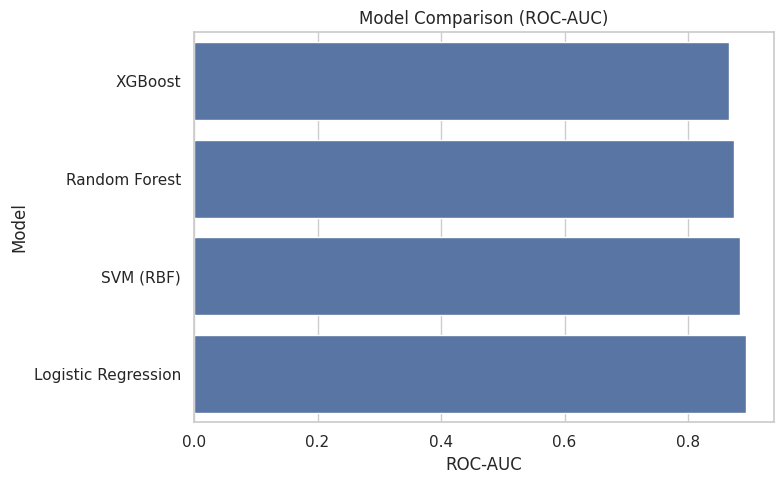

In [41]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cv_results.sort_values("ROC-AUC", ascending=True),
    x="ROC-AUC",
    y="Model"
)
plt.title("Model Comparison (ROC-AUC)")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### 6.5 Interpretation of Results

The comparison highlights several important findings:

- **Logistic Regression** achieves the best cross-validated ROC-AUC, indicating that a relatively simple and interpretable linear model already captures strong predictive signal in the data.

- **SVM** also performs well, suggesting that non-linear decision boundaries provide additional flexibility without dramatically outperforming the linear baseline.

- **Random Forest** and **XGBoost** remain competitive, but in this dataset they do not outperform Logistic Regression in cross-validation.

### Trade-offs

- **Logistic Regression** offers the strongest balance between performance and interpretability.
- **SVM** provides competitive performance but is less directly interpretable.
- **Tree-based ensemble models** may still be valuable because they can capture non-linear interactions and can be further assessed after tuning.

### Key Takeaway

The results suggest that the dataset contains strong signal that can already be captured by simpler models, while more flexible models remain worth exploring as alternative finalists.

### 6.6 Model Selection for Tuning

Rather than selecting a single final model immediately, we retain the most promising candidates for further tuning:

- **Logistic Regression** as the strongest interpretable baseline
- **XGBoost** as a flexible non-linear model

This balanced strategy allows us to compare predictive performance against interpretability in the next step.

### Summary

- Models were compared using leakage-free pipelines and stratified cross-validation
- Multiple evaluation metrics were used to capture complementary aspects of performance
- Logistic Regression emerged as the strongest baseline
- More flexible models remain useful finalists for further refinement

Next, we perform hyperparameter tuning on the selected finalist models.

## 7. Hyperparameter Tuning

After comparing baseline models, we refine the most promising candidates through hyperparameter tuning.

### Objective
The goal of this step is to improve model performance while controlling overfitting and preserving a fair evaluation strategy.

Rather than tuning every model, we focus on a small number of strong candidates:
- **Logistic Regression** → best interpretable baseline
- **XGBoost** → strong non-linear ensemble candidate

This selective approach keeps the analysis efficient and methodologically sound.

### 7.1 Selection Rationale

The baseline comparison showed that different model families perform competitively.

We retain:
- **Logistic Regression**, because it offers interpretability and often performs surprisingly well on structured tabular data
- **XGBoost**, because boosting methods are strong candidates for capturing non-linear interactions and feature combinations

This allows us to compare:
- a simpler, more explainable model
- a more flexible, high-capacity model

### ⚙️ 7.2 Logistic Regression Tuning

For Logistic Regression, the most important hyperparameter is the regularization strength `C`, which controls the trade-off between bias and variance.

In [42]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

param_dist_lr = {
    "model__C": np.logspace(-3, 2, 30),
    "model__solver": ["liblinear", "lbfgs"]
}

search_lr = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_lr.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(search_lr.best_params_)
print(f"Best CV ROC-AUC: {search_lr.best_score_:.4f}")

Best Logistic Regression parameters:
{'model__solver': 'lbfgs', 'model__C': np.float64(0.38566204211634725)}
Best CV ROC-AUC: 0.8969


### 7.3 XGBoost Tuning

For XGBoost, we tune a subset of influential hyperparameters related to:
- model complexity
- learning speed
- robustness
- subsampling

In [43]:
pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_dist_xgb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 2, 3, 5]
}

search_xgb = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search_xgb.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(search_xgb.best_params_)
print(f"Best CV ROC-AUC: {search_xgb.best_score_:.4f}")

Best XGBoost parameters:
{'model__subsample': 0.7, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}
Best CV ROC-AUC: 0.8970


### 7.4 Tuned Model Comparison

We compare model performance before and after tuning to assess the impact of hyperparameter optimization.

In [44]:
tuned_results = pd.DataFrame([
    {
        "Model": "Tuned Logistic Regression",
        "Best CV ROC-AUC": search_lr.best_score_
    },
    {
        "Model": "Tuned XGBoost",
        "Best CV ROC-AUC": search_xgb.best_score_
    }
]).sort_values("Best CV ROC-AUC", ascending=False).reset_index(drop=True)

tuned_results

,Model,Best CV ROC-AUC
0,Tuned XGBoost,0.896952
1,Tuned Logistic Regression,0.896884


In [45]:
baseline_scores = cv_results.set_index("Model")["ROC-AUC"]

comparison = pd.DataFrame({
    "Baseline": baseline_scores.loc[[
        "Logistic Regression", "XGBoost"
    ]].values,
    "Tuned": [
        search_lr.best_score_,
        search_xgb.best_score_
    ]
}, index=["Logistic Regression", "XGBoost"])

comparison

,Baseline,Tuned
Logistic Regression,0.894525,0.896884
XGBoost,0.866470,0.896952


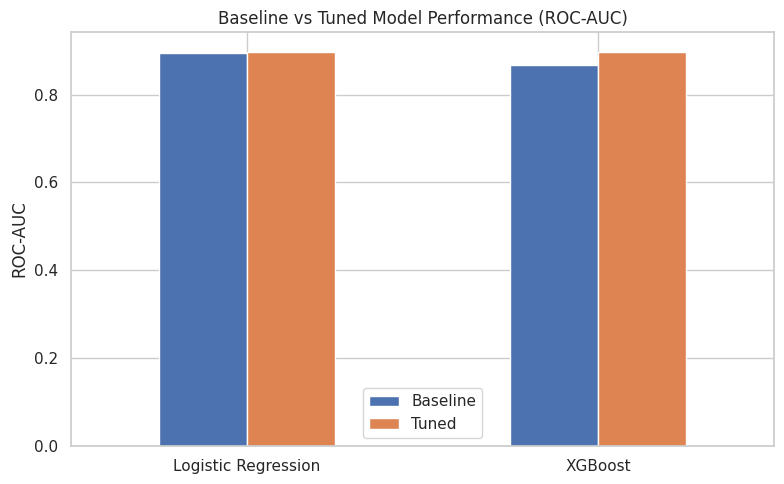

In [46]:
comparison.plot(kind="bar", figsize=(8,5))
plt.title("Baseline vs Tuned Model Performance (ROC-AUC)")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

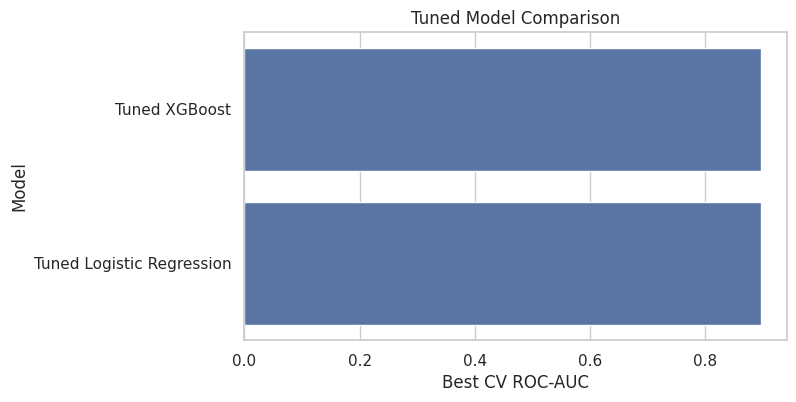

In [47]:
plt.figure(figsize=(7, 4))
sns.barplot(data=tuned_results, x="Best CV ROC-AUC", y="Model")
plt.title("Tuned Model Comparison")
plt.show()

### 7.5 Interpretation

Hyperparameter tuning led to modest but measurable improvements:

- **Logistic Regression** improved slightly, confirming that it already captured most of the linear signal in the data.
- **XGBoost** also improved and achieves the best overall performance, although the gain remains limited.

### Key Insight

The relatively small improvement suggests that:

- The dataset already contains strong signal that is easily captured by baseline models.
- Model complexity does not dramatically improve performance, likely due to the small dataset size (~300 samples).

### Trade-off

- **Logistic Regression** remains highly competitive and offers full interpretability.
- **XGBoost** provides slightly better performance but at the cost of increased complexity.

### Conclusion

Both models are retained as final candidates:
- Logistic Regression → best interpretable model  
- XGBoost → best-performing flexible model  

Final selection will be based on evaluation on the unseen test set.

## 8. Final Model Evaluation

After tuning the finalist models, we now evaluate them on the **held-out test set**.

### Objective
The goal of this step is to assess how well each model generalizes to unseen data.

This is a critical stage because:
- Cross-validation helps estimate model robustness
- The test set provides the final unbiased evaluation

### Evaluation Metrics

Given the medical context, we evaluate models using multiple complementary metrics:

- **Accuracy** → overall correctness
- **Precision** → reliability of positive predictions
- **Recall** → ability to detect disease cases
- **F1-score** → balance between precision and recall
- **ROC-AUC** → ranking performance across thresholds

This multi-metric view is important because, in healthcare settings, a model with high accuracy but poor recall may still be unsuitable.

### 8.1 Finalists

We retain the best estimators obtained during hyperparameter tuning:
- Tuned Logistic Regression
- Tuned XGBoost

In [48]:
finalists = {
    "Tuned Logistic Regression": search_lr.best_estimator_,
    "Tuned XGBoost": search_xgb.best_estimator_
}

### 8.2 Test Set Evaluation

We evaluate both tuned models on the unseen test set and compare their performance.

In [49]:
test_results = []

for name, model in finalists.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

test_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.969697
1,Tuned XGBoost,0.885246,0.862069,0.892857,0.877193,0.965368


### 8.3 Performance Comparison

A visual comparison makes it easier to identify the strongest final candidate.

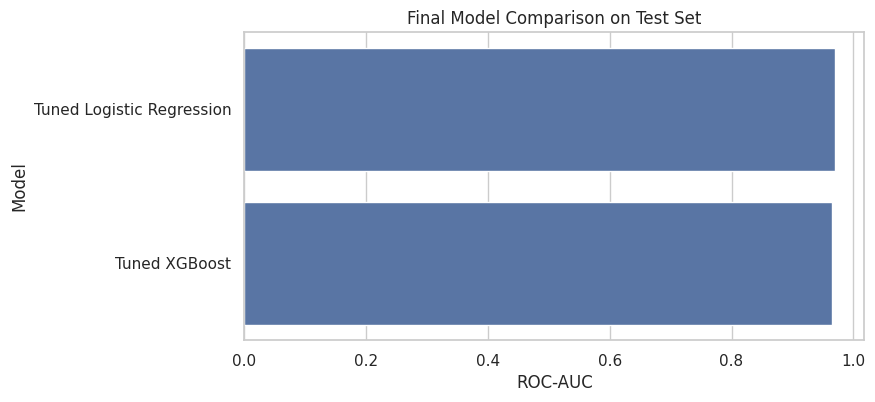

In [50]:
plt.figure(figsize=(8, 4))
sns.barplot(data=test_results_df, x="ROC-AUC", y="Model")
plt.title("Final Model Comparison on Test Set")
plt.show()

### 8.4 Final Model Selection

Although both models achieve very similar ROC-AUC scores, we prioritize **recall** in this medical context.

- **Logistic Regression** achieves higher recall (0.93), meaning it identifies more patients with heart disease.
- **XGBoost** provides slightly better accuracy and F1-score.

### Final Decision

We select **Tuned Logistic Regression** as the final model because:

- It achieves the highest ROC-AUC
- It provides **superior recall**, reducing the risk of missing true positive cases
- It remains fully interpretable, which is important in healthcare applications

In [51]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = finalists[best_model_name]

print("Selected final model:", best_model_name)

Selected final model: Tuned Logistic Regression


### 8.5 Detailed Evaluation of the Selected Model

We now examine the selected model in more detail using:
- classification report
- confusion matrix

In [52]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=["No Disease", "Disease"]))

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



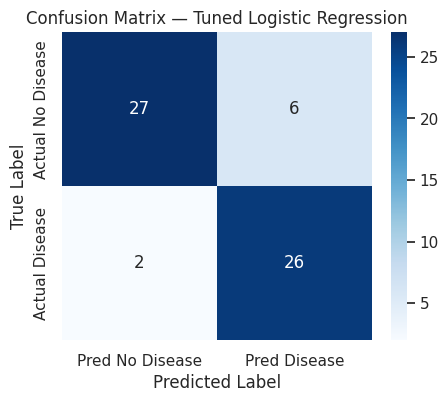

In [53]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred No Disease", "Pred Disease"],
    yticklabels=["Actual No Disease", "Actual Disease"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 8.6 ROC Curve

The ROC curve helps visualize the trade-off between sensitivity and specificity across thresholds.

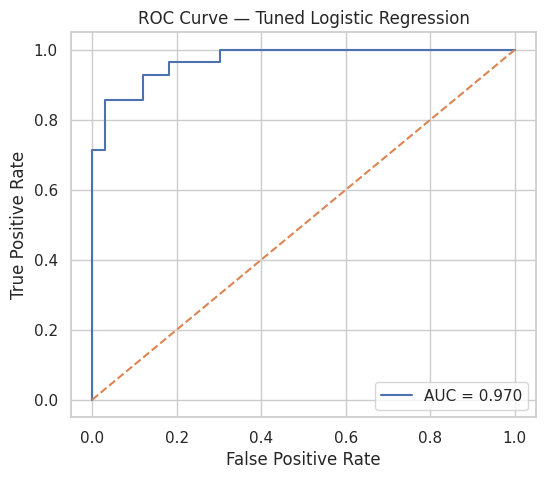

In [54]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.legend(loc="lower right")
plt.show()

### 8.7 Interpretation

The evaluation on the held-out test set confirms strong model performance:

- **ROC-AUC ≈ 0.97** indicates excellent ranking ability.
- **Recall (0.93)** shows the model is highly effective at detecting patients with heart disease.
- The confusion matrix reveals only **2 false negatives**, which is critical in a medical setting.

### Key Insight

The model successfully balances performance and clinical relevance:

- High recall minimizes missed diagnoses
- Good precision (0.81) keeps false alarms at a reasonable level

### Trade-off

Some false positives are accepted in exchange for higher recall, which is often desirable in healthcare screening scenarios.

### Conclusion

The model demonstrates strong generalization ability and is suitable for decision-support applications, provided its predictions are interpreted alongside clinical expertise.

## 9. Threshold Analysis

By default, classification models use a decision threshold of **0.5** to convert predicted probabilities into class labels.

However, this threshold is **not always optimal**, especially in sensitive domains such as healthcare.

### Objective

The goal of this section is to analyze how different thresholds affect:
- Precision
- Recall
- F1-score
- Specificity

This allows us to adapt the model to different real-world use cases.

### 9.1 Why Threshold Selection Matters

In a medical context, the choice of threshold has direct consequences:

- **Low threshold (e.g., 0.3)**
  - More patients flagged as at risk
  - Higher **recall**
  - More false positives

- **High threshold (e.g., 0.7)**
  - Fewer patients flagged
  - Higher **precision**
  - More missed cases (false negatives)

### Key Trade-off

- Missing a disease (false negative) can be critical  
- Raising false alarms (false positives) has a lower cost  

Therefore, threshold selection should depend on the **intended use case**.

### 9.2 Metric Evaluation Across Thresholds

We evaluate performance across a range of thresholds to understand trade-offs.




In [55]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_metrics = []

for thr in thresholds:
    y_thr = (y_prob_best >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_thr).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    threshold_metrics.append({
        "threshold": thr,
        "precision": precision_score(y_test, y_thr, zero_division=0),
        "recall": recall_score(y_test, y_thr, zero_division=0),
        "f1": f1_score(y_test, y_thr, zero_division=0),
        "specificity": specificity
    })

threshold_df = pd.DataFrame(threshold_metrics)
threshold_df

,threshold,precision,recall,f1,specificity
0,0.10,0.595745,1.000000,0.746667,0.424242
1,0.15,0.651163,1.000000,0.788732,0.545455
2,0.20,0.682927,1.000000,0.811594,0.606061
3,0.25,0.700000,1.000000,0.823529,0.636364
4,0.30,0.736842,1.000000,0.848485,0.696970
5,0.35,0.771429,0.964286,0.857143,0.757576
6,0.40,0.794118,0.964286,0.870968,0.787879
7,0.45,0.818182,0.964286,0.885246,0.818182
8,0.50,0.812500,0.928571,0.866667,0.818182
9,0.55,0.866667,0.928571,0.896552,0.878788


### 9.3 Threshold Performance Curves

We visualize how evaluation metrics evolve with the decision threshold.

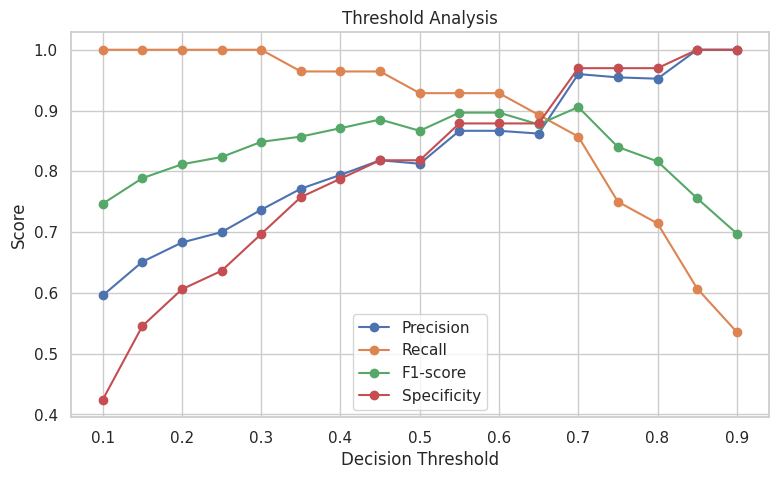

In [56]:
plt.figure(figsize=(9, 5))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1-score")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="Specificity")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.show()

### 9.4 Selecting an Optimal Threshold

Different strategies can be used depending on the objective.

In [57]:
best_thr_f1 = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]
print("Best threshold (F1-score):", round(best_thr_f1, 2))

Best threshold (F1-score): 0.7


This threshold provides the best balance between precision and recall.




In [58]:
recall_target = threshold_df[threshold_df["recall"] >= 0.85]

if not recall_target.empty:
    best_thr_recall = recall_target.sort_values("precision", ascending=False).iloc[0]["threshold"]
    print("Threshold favoring high recall:", round(best_thr_recall, 2))
else:
    print("No threshold reaches recall ≥ 0.85")

Threshold favoring high recall: 0.7


This strategy prioritizes detecting as many at-risk patients as possible, even at the cost of more false positives.



### 9.5 Interpretation

The threshold analysis reveals clear and quantifiable trade-offs:

- At **low thresholds (0.1–0.3)**:
  - Recall is maximized (**≈ 1.0**)
  - Precision is significantly lower (≈ 0.60–0.73)
  - Many false positives are introduced

- At the default threshold (**0.5**):
  - Balanced performance (F1 ≈ 0.87)
  - Recall remains high (**0.93**)
  - Precision improves (**0.81**)

- At higher thresholds (**0.7+**):
  - Precision becomes very high (**≈ 0.96–1.0**)
  - Recall drops significantly (**≈ 0.75 → 0.53**)
  - More true disease cases are missed

### Key Insight

The optimal threshold based on **F1-score is 0.7**, which provides the best balance between precision and recall.

However, this comes at the cost of reduced recall compared to lower thresholds.

### Practical Framing of Threshold Selection

Threshold selection depends on the intended use case:

- In a screening setting, a lower threshold may be preferred to maximize sensitivity and reduce false negatives.
- In a balanced decision setting, a threshold maximizing F1-score may be appropriate.
- In a confirmatory setting, a higher threshold may help reduce false positives.

For this reason, threshold tuning should not be viewed as purely mathematical, but as a decision aligned with the clinical objective.

### Choosing the Right Threshold

The optimal threshold depends on the application context:

- **Screening scenario (high recall priority)**  
  → Use threshold ≈ **0.4–0.5**  
  → Captures most disease cases while maintaining reasonable precision  

- **Balanced performance (F1 optimal)**  
  → Use threshold ≈ **0.7**  

- **High precision scenario (confirmatory use)**  
  → Use threshold ≥ **0.8**  
  → Minimizes false positives but increases missed cases  

### Recommendation

Given the medical context where missing a disease is critical, a threshold slightly **below the F1 optimum (e.g., 0.5–0.6)** may be more appropriate.

## 10. Calibration Analysis

While metrics such as ROC-AUC evaluate ranking performance, they do not indicate whether predicted probabilities are **reliable**.

### Objective

Calibration analysis answers the question:

> “If the model predicts a 70% risk, does that correspond to a true 70% probability in reality?”

This is particularly important in healthcare, where predicted probabilities may directly influence decisions.

### Why Calibration Matters

- A model can have high ROC-AUC but poorly calibrated probabilities
- Poor calibration can lead to:
  - Overestimating risk → unnecessary interventions
  - Underestimating risk → missed diagnoses

We evaluate calibration using:
- Calibration curve
- Brier score

### 10.1 Calibration Curve

The calibration curve compares:
- Predicted probabilities
- Observed outcomes

A perfectly calibrated model follows the diagonal line.

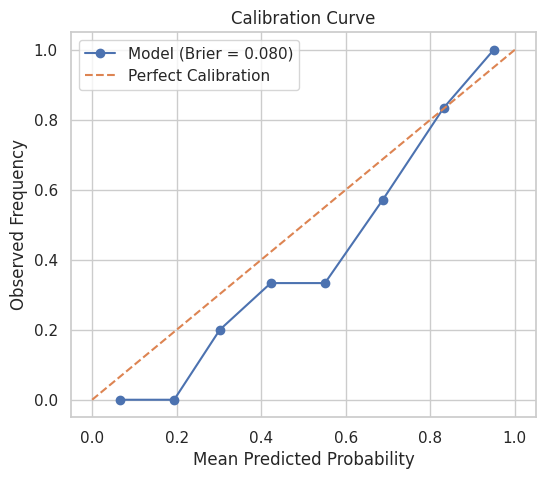

In [59]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_best, n_bins=8)

brier = brier_score_loss(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label=f"Model (Brier = {brier:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

### 🧠 10.2 Interpretation

The calibration curve shows that the model is already reasonably well calibrated, with predictions close to the diagonal.

The Brier score confirms this:
- Original model: **0.0805**
- Calibrated model: **0.0825**

👉 Calibration slightly **degrades performance** in this case.

### 🎯 Key Insight

This indicates that:
- The original model already produces well-calibrated probabilities
- Additional calibration is **not beneficial** and may introduce noise due to the small dataset size

### ⚠️ Why Calibration Did Not Help

Several factors explain this result:

- The dataset is relatively small (~300 samples)
- Logistic Regression is naturally well-calibrated
- Cross-validation inside calibration may introduce variance

👉 As a result, applying calibration does not improve probability estimates and may slightly degrade them.

### 🔧 10.3 Optional Calibration Improvement

If calibration is suboptimal, we can apply calibration techniques such as:
- **Sigmoid (Platt scaling)**
- **Isotonic regression**

Here we use sigmoid calibration.

In [60]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

calibrated_model = CalibratedClassifierCV(
    estimator=clone(best_model),
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

y_prob_cal = calibrated_model.predict_proba(X_test)[:, 1]

print("Original Brier Score :", round(brier_score_loss(y_test, y_prob_best), 4))
print("Calibrated Brier Score:", round(brier_score_loss(y_test, y_prob_cal), 4))

Original Brier Score : 0.0805
Calibrated Brier Score: 0.0825


### 📈 10.4 Calibration Comparison

We compare the original and calibrated probabilities.

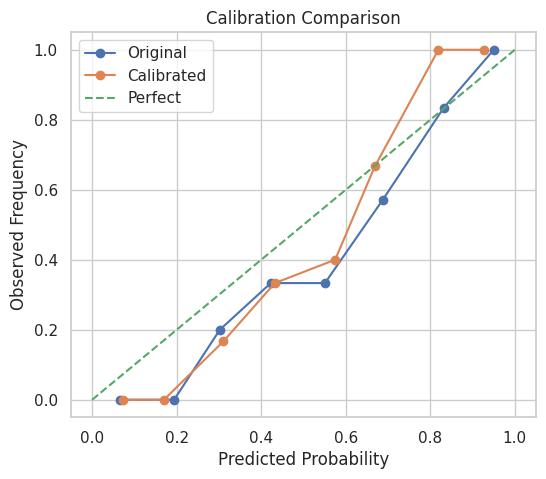

In [61]:
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal, n_bins=8)

plt.figure(figsize=(6, 5))

plt.plot(prob_pred, prob_true, marker="o", label="Original")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Comparison")
plt.legend()
plt.show()

### Practical Decision

Since calibration does not improve performance:

- We **retain the original model probabilities**
- We avoid unnecessary model complexity
- We keep the pipeline simpler and more stable

-> This aligns with the principle of **Occam’s Razor** in modeling:
prefer the simplest solution that performs well.

### 10.5 Practical Insight

Calibration is essential when predicted probabilities are used for decision-making:

- A well-calibrated model allows clinicians to:
  - Interpret risk levels reliably
  - Define meaningful intervention thresholds

- For example:
  - “Patients with >70% predicted risk should undergo further testing”

Without proper calibration, such thresholds may be misleading.

### Summary

- Calibration evaluates the reliability of predicted probabilities
- A model can perform well in ROC-AUC but still be poorly calibrated
- Calibration techniques can improve probability estimates

This step strengthens the model’s usability in real-world decision-making scenarios.

## 11. Model Explainability

In healthcare-related machine learning tasks, predictive performance alone is not sufficient.  
It is equally important to understand **which features drive predictions** and **why a given patient is classified as high or low risk**.

### Objectives

This section addresses two complementary levels of explainability:

- **Global explainability** → identify the most influential features across the full dataset
- **Local explainability** → understand the drivers of an individual prediction

To achieve this, we use **SHAP (SHapley Additive exPlanations)**, a widely used framework that provides consistent feature attribution at both global and local levels.

### 11.1 SHAP Setup

We start by importing SHAP and preparing the transformed test data used by the final model.

In [63]:
# Access the fitted preprocessing pipeline from the selected final model
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_model = best_model.named_steps["model"]

# Transform test data
X_test_transformed = fitted_preprocessor.transform(X_test)

# Retrieve transformed feature names
feature_names = fitted_preprocessor.named_steps["column_transformer"].get_feature_names_out()

print("Transformed test shape:", X_test_transformed.shape)
print("Number of transformed features:", len(feature_names))
feature_names[:15]

Transformed test shape: (61, 34)
Number of transformed features: 34


array(['num__age', 'num__trestbps', 'num__chol', 'num__thalach',
       'num__oldpeak', 'num__hr_age_ratio', 'num__oldpeak_thalach_ratio',
       'cat__sex_0.0', 'cat__sex_1.0', 'cat__cp_1.0', 'cat__cp_2.0',
       'cat__cp_3.0', 'cat__cp_4.0', 'cat__fbs_0.0', 'cat__fbs_1.0'],
      dtype=object)

### 11.2 Global Explainability

We first examine which features contribute the most to model predictions overall.

This helps answer questions such as:
- Which variables are most influential?
- Are the model’s main drivers clinically plausible?
- Does the model rely on meaningful patterns?

### 11.3 SHAP Global Explanation

Since the final selected model is **Tuned Logistic Regression**, SHAP is used to quantify how each transformed feature contributes to the model’s predictions on the test set.

In [64]:
# Build SHAP explainer for the final selected model: Tuned Logistic Regression
explainer = shap.Explainer(
    fitted_model,
    X_test_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_test_transformed)

print("SHAP values computed successfully.")

SHAP values computed successfully.


### 11.4 SHAP Summary Plot

The SHAP summary plot provides a global view of feature impact across all observations.

Interpretation:
- Features at the top are the most influential overall
- Color reflects feature value (low to high)
- Position on the x-axis reflects whether a feature pushes the prediction toward lower or higher estimated probability of heart disease

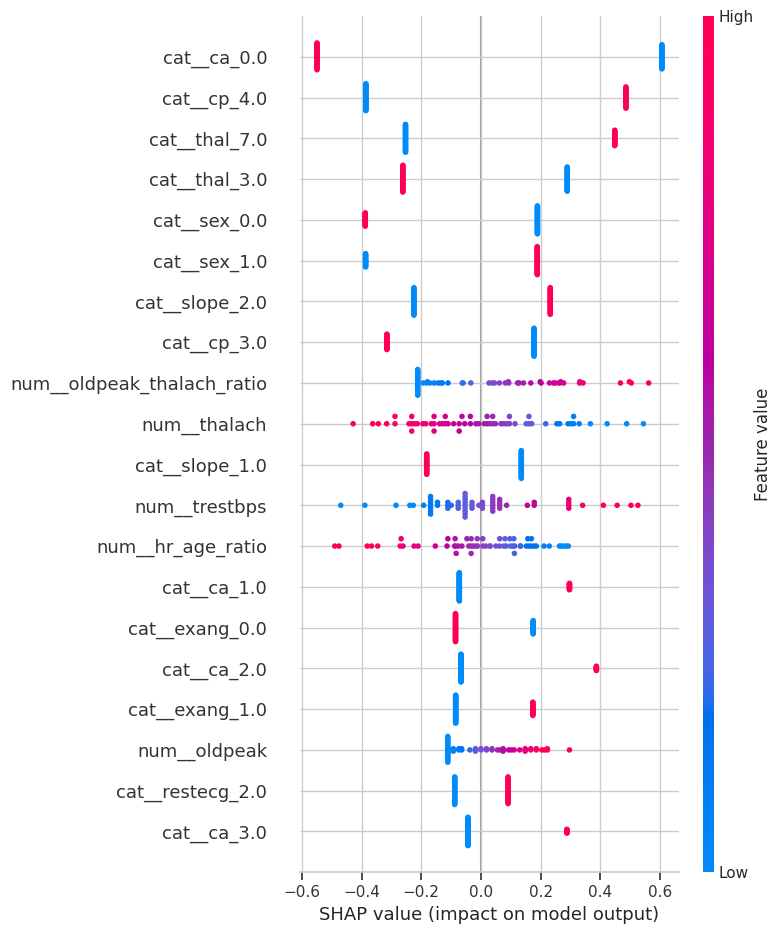

In [65]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

### 11.5 Mean Absolute SHAP Importance

To complement the summary plot, we also visualize the average absolute contribution of each feature.

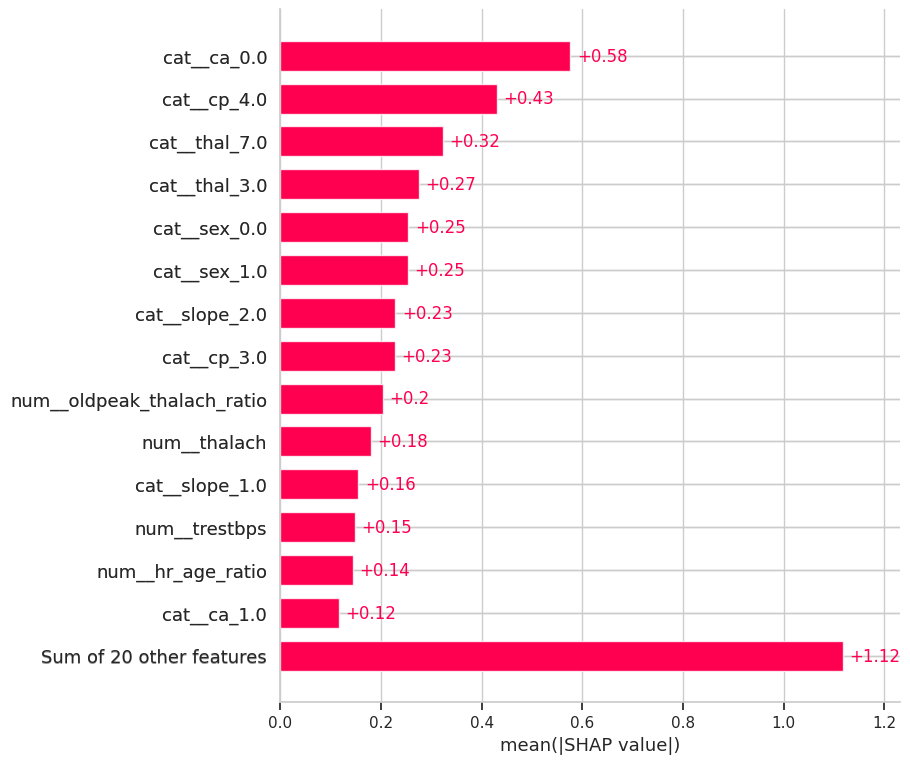

In [66]:
shap.plots.bar(shap_values, max_display=15)

### 11.6 Local Explainability

Global explainability helps understand the model overall, but clinical decision support also requires understanding **individual predictions**.

We therefore inspect one correctly predicted positive case using a SHAP waterfall plot to illustrate how the model combines multiple feature contributions at the individual level.

In [67]:
# Predictions on test set
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Try to find a true positive example
tp_indices = np.where((y_test.values == 1) & (y_pred_best == 1))[0]

if len(tp_indices) > 0:
    patient_idx = int(tp_indices[0])
    example_type = "True Positive"
else:
    patient_idx = 0
    example_type = "Default Example"

print("Selected patient index:", patient_idx)
print("Example type:", example_type)
print("Predicted probability:", round(y_prob_best[patient_idx], 3))
print("True label:", y_test.iloc[patient_idx] if hasattr(y_test, "iloc") else y_test[patient_idx])
print("Predicted label:", y_pred_best[patient_idx])

Selected patient index: 8
Example type: True Positive
Predicted probability: 0.703
True label: 1
Predicted label: 1


### 11.8 SHAP Waterfall Plot for One Patient

The waterfall plot shows how the model starts from a baseline prediction and adjusts it feature by feature to arrive at the final prediction for the selected patient.

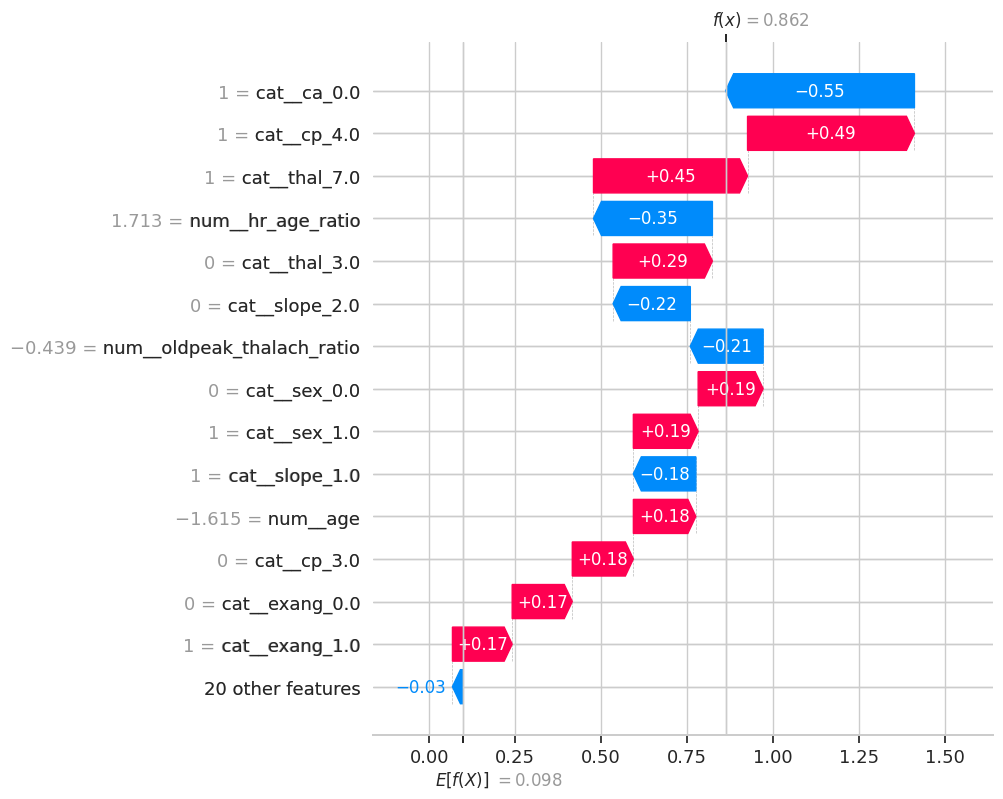

In [68]:
shap.plots.waterfall(shap_values[patient_idx], max_display=15)

### 11.9 Original Patient Profile

To make the local explanation easier to interpret, we also display the original patient features.

In [69]:
X_test.iloc[[patient_idx]].T.rename(columns={X_test.index[patient_idx]: "Selected Patient"})

,Selected Patient
age,35.0
sex,1.0
cp,4.0
trestbps,126.0
chol,282.0
fbs,0.0
restecg,2.0
thalach,156.0
exang,1.0
oldpeak,0.0


### 11.10 Interpretation

#### **Global Interpretation**

The SHAP summary plot highlights the variables that contribute most strongly to the model’s predictions.

Several patterns appear consistent with the earlier exploratory analysis:

- **oldpeak**: higher values tend to push predictions toward higher risk
- **thalach**: lower values tend to increase predicted risk
- **cp**: some chest pain categories contribute more strongly to higher predicted risk than others
- **ca**: higher values are associated with increased predicted risk
- **thal**: certain categories are also associated with higher risk predictions

These results are broadly consistent with clinically plausible cardiovascular risk patterns. However, they should be interpreted as **model-level associations**, not as causal medical conclusions.

#### **Feature Encoding Note**

Categorical variables are one-hot encoded (for example, `cat__cp_4.0` or `cat__ca_0.0`), so SHAP values reflect the contribution of specific encoded categories rather than the original raw variable directly.

This explains why several transformed features may correspond to the same underlying clinical variable.

#### **Local Interpretation (Selected Patient)**

The waterfall plot explains how the model combines feature contributions for one individual patient.

For the selected patient, some features push the prediction toward higher risk, while others reduce it. The final predicted probability reflects the net effect of these competing contributions.

For example, features related to chest pain type, thal category, or ST depression may increase the predicted risk, while others may offset part of that effect depending on the patient profile.

#### **Important Interpretation Caution**

SHAP values explain how the model uses the available features to generate predictions. They should therefore be interpreted as model-level associations rather than causal clinical conclusions. A feature appearing important in SHAP does not necessarily mean it is an independent medical cause of disease.

#### **Why This Matters**

Explainability helps make the model more transparent by showing which features drive predictions globally and how individual patient-level predictions are formed. In a healthcare-oriented setting, this is especially useful for improving interpretability and supporting more informed review of model outputs.

### 11.11 Explainability Scope

This notebook focuses primarily on **SHAP** for both global and local explainability.  
Other local explainability approaches such as **LIME** could also be explored as complementary methods, but they are not central to the present analysis.

### 11.12 Summary

- SHAP was used to explain the final model at both global and local levels
- Global analysis identified the most influential predictive features
- Local analysis showed how feature contributions combine for an individual patient
- The explanations increase transparency and support trust in the model’s predictions

This strengthens the practical value of the model, especially in a healthcare-oriented decision-support setting.

## 12. Limitations and Future Improvements

While the results are promising, several limitations should be acknowledged.

### Limitations

- **Small dataset size (~300 samples)**  
  The limited number of observations increases the risk of overfitting and may lead to optimistic performance estimates, even with cross-validation.

- **Potential data bias**  
  The dataset may not fully represent diverse or contemporary patient populations, limiting generalizability.

- **Missing values and preprocessing assumptions**  
  Although handled through imputation, missing data and preprocessing choices may introduce uncertainty or bias in feature distributions.

- **Binary simplification of the target**  
  The original dataset contains multiple severity levels, which were reduced to a binary classification problem.  
  While this simplifies modeling, it removes potentially valuable clinical granularity.

- **Limited external validation**  
  The model was evaluated on a single dataset split.  
  Real-world deployment would require validation on independent and more recent datasets.

- **Explainability limitations**  
  SHAP explanations depend on the model and feature representation (e.g., one-hot encoding), which may make interpretation less intuitive.

---

### Future Improvements

- Use larger, more recent, and more diverse datasets  
- Perform external validation on independent cohorts  
- Explore multi-class or ordinal classification for disease severity  
- Integrate domain knowledge or clinical constraints into the model  
- Evaluate model stability across different data splits  
- Explore ensemble stacking if additional performance gains are required  
- Deploy the model in a simulated or real clinical workflow for validation  

---

### Key Takeaway

Acknowledging these limitations is essential to ensure responsible and realistic use of machine learning models, particularly in high-stakes domains such as healthcare.

## 13. Conclusion

This notebook presents a complete and structured data science pipeline for heart disease prediction, from exploratory analysis to model explainability.

---

### Summary of Contributions

- Conducted a structured exploratory data analysis (EDA) to understand key variables  
- Built a leakage-free preprocessing and modeling pipeline using scikit-learn  
- Compared multiple model families using stratified cross-validation  
- Performed hyperparameter tuning on selected candidates  
- Evaluated final models on a held-out test set  
- Conducted threshold analysis to adapt predictions to real-world needs  
- Assessed probability calibration and validated its usefulness  
- Applied SHAP for both global and local explainability  

---

### Final Model Choice

The selected model is **Tuned Logistic Regression**, because it provides:

- Strong predictive performance (ROC-AUC ≈ 0.97)  
- High recall, which is critical in medical screening contexts  
- Natural interpretability  
- Well-calibrated probability estimates without requiring additional calibration  

-> This combination makes it a robust and practical choice.

---

### Practical Perspective

This model is designed as a **decision-support tool**, not a replacement for clinical expertise.

- For **screening**, thresholds can be lowered to prioritize recall  
- For **diagnostic support**, thresholds can be increased to improve precision  

-> The flexibility of threshold selection is key for real-world deployment.

---

### Final Takeaway

This project demonstrates that effective machine learning is not only about maximizing performance, but about balancing:

- **Performance**
- **Interpretability**
- **Reliability**
- **Practical usability**

-> This balance is essential for building trustworthy AI systems, especially in healthcare.